In [ ]:
import os
import cv2
import math
import torch
import random
import torchvision
import numpy as np
import pandas as pd
import torch.nn as nn
from datetime import date
from skimage import io, color
from google.colab import drive
from torchvision import models
import skimage.morphology as mo
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image, ImageFilter
from scipy.ndimage import median_filter
from torch.utils.data import random_split
import torchvision.transforms.functional as TF
from torch.utils.data  import Dataset, DataLoader
from sklearn.model_selection import train_test_split


from torchvision import transforms
from torch.autograd import Variable
from torchvision.utils import save_image
# from utils import *
# import timm
# from timm.models.layers import DropPath, to_2tuple, trunc_normal_
# import types

drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images'
patients = os.listdir(root_dir)
total = 0
for patient in patients:
  total += len(os.listdir(os.path.join(root_dir, patient)))
print(total)

722


# Get our labels from excel file and turn it into a dictionary

Read csv data into a dataframe and collect all patient 'Study ID'. Print out number of patients in csv file and in folder. Number of patients in folder determine our dataset size for training and testing.

In [ ]:
df = pd.read_csv('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/Data_11.5.23_modified.csv')
patients = df['Study_ID']
folders = os.listdir('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images')
print('Number of patients in csv file: ', len(patients))
print('Number of patients in folder: ', len(folders))

Number of patients in csv file:  65
Number of patients in folder:  65


Create two dictionary, using 'Study ID' as key, and ['FM', 'FFM', 'Weight_visit', 'Length_visit'] as value. Create the test dictionary from the training dictionary.

In [ ]:
labels_dict = df.set_index('Study_ID')[['FM', 'FFM', 'Weight_visit', 'Length_visit']].apply(list, axis=1).to_dict()
test_data = [17042418, 9021218, 35080318, 58041919, 65050619, 57032919, 50102518]#, , , 57032919, 67062119, 60042419, 44091318]
test_labels_dict = {k: labels_dict[k] for k in test_data if k in labels_dict}
for i in test_data:
  del labels_dict[i]
PATIENTS = [str(num) for num in test_data]
print(len(labels_dict))
print(len(test_labels_dict))

58
7


# Functions

In [ ]:
class PatientDataset(Dataset):
    def __init__(self, transform = None,
                 augmented_dataset = False, # Determine if we want to augment entire dataset instead of augmenting individual image
                 augment = 0, # this can be 0 (no augmentation), 5 (augment by 4 times plus original image), 8 and 15
                 threshold = False, # Remove all pixels under a certain threshold
                 speckle = False, # Apply median filter
                 despeckle = False, # Apply fast NL mean denoising
                 region_combination = "BAQ", # this can be B, A, Q, BA, BQ, AQ, BAQ
                 number_of_image = 3, # this can be 1, 2, 3, number of image for each region
                 crop = [1, 1, 1], # Only keep the x percentage of the image in the order of Abdomen, Biceps, and Quadriceps
                 output = "FM" # this can be FM or FFM, depending on which we want to predict
                 ):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images'
        self.patients = os.listdir(self.root_dir)
        for data in test_data:
          self.patients.remove(str(data))
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.region_combination = region_combination
        self.number_of_image = number_of_image
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        images = self.load_patient_data(patient_path)
        label_FM = labels_dict[int(patient_id)][0]
        label_FFM = labels_dict[int(patient_id)][1]
        if self.output == "FM":
          return images, label_FM, labels_dict[int(patient_id)][2], labels_dict[int(patient_id)][3]
        if self.output == "FFM":
          return images, label_FFM, labels_dict[int(patient_id)][2], labels_dict[int(patient_id)][3]

    def preprocess(self, img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, crop):
        image = Image.open(img_path)
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height*crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
          image = image.filter(ImageFilter.MedianFilter(size=MF_size))
        if self.threshold:
          image = torch.where(image < threshold/255, torch.tensor(0.0), image)
        if self.despeckle:
          image_np = np.array(image)
          despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=10, templateWindowSize=7, searchWindowSize=21)
          image = Image.fromarray(despeckled_image)
        if not self.augmented_dataset:
          image = self.transform(image)
        images.append(image)

        ## Augmentation
        # Augment by 5 times
        if self.augment >= 5:
          imx = image
          imx = TF.hflip(imx)
          images.append(imx)
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        # Augment by 8 times
        if self.augment >= 8:
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        # Augment by 15 times
        if self.augment >= 15:
          imx = image
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([30])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        return images

    def load_patient_data(self, patient_path):
        images = []
        threshold = 100
        AB = 0
        BICEP = 0
        QUAD = 0
        MF_size = 5
        h = 10
        templateWindowSize = 7
        searchWindowSize = 21
        for img_file in os.listdir(patient_path):
          # Process Abdomen images
          if 'A' in self.region_combination and '_A' in img_file and AB < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[0])
              AB += 1
          # Process Bicep images
          elif 'B' in self.region_combination and '_B' in img_file and BICEP < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[1])
              BICEP += 1
          # Process Quad images
          elif 'Q' in self.region_combination and '_Q' in img_file and QUAD < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[2])
              QUAD += 1
        return images

In [ ]:
class AugmentedPatientDataset(Dataset):
    def __init__(self, original_dataset, transform = None, augmentations=5):
        self.original_dataset = original_dataset
        self.augmentations = augmentations
        self.transform = transform

    def __len__(self):
        # Multiply the length by the number of augmentations
        return len(self.original_dataset) * self.augmentations

    def __getitem__(self, idx):
        original_idx = idx // self.augmentations
        augmentation_state = idx % self.augmentations

        # Fetch the list of images and label for the original index
        images_list, label = self.original_dataset[original_idx]

        # Initialize an empty list to store augmented images
        augmented_images_list = []

        # Apply the same augmentation to each image in the list
        for image in images_list:
            augmented_image = self.apply_augmentation(image, augmentation_state)
            augmented_image = self.transform(augmented_image)
            augmented_images_list.append(augmented_image)

        return augmented_images_list, label

    def apply_augmentation(self, image, state):
        # Ensure image is a PIL Image for torchvision transforms
        if not isinstance(image, Image.Image):
            raise TypeError(f"Expected PIL Image, but got {type(image)}")

        # Apply augmentation based on state
        if state == 1:
            return TF.hflip(image)
        elif state == 2:
            return TF.vflip(image)
        elif state == 3:
            #angle = 30  # Example rotation
            angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
            return TF.rotate(image, angle)
        elif state == 4:
            #angle = 30  # Example rotation
            angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
            return TF.rotate(image, angle)
        # Add more augmentation states if needed
        return image  # Return the original image for state 0 or any undefined state

In [ ]:
def im_converterX(tensor):
  image = tensor.cpu().clone().detach().numpy()
  image = image.transpose(1,2,0)
  image = image * np.array((1, 1, 1))
  image = image.clip(0, 1)
  return image

In [ ]:
class MAPELoss(nn.Module):
    def __init__(self):
        super(MAPELoss, self).__init__()

    def forward(self, input, target):
        """
        Calculate the Mean Absolute Percentage Error (MAPE) between `input` and `target`.
        """
        return torch.mean(torch.abs((target - input) / target)) * 100

In [ ]:
class CustomLoss(nn.Module):
    def __init__(self, weight_mse=0.6, weight_l1=0.4):
        super(CustomLoss, self).__init__()
        self.weight_mse = weight_mse
        self.weight_l1 = weight_l1
        self.mse_loss = nn.MSELoss()
        self.l1_loss = nn.L1Loss()

    def forward(self, input, target):
        mse_loss = self.mse_loss(input, target)
        l1_loss = self.l1_loss(input, target)
        total_loss = self.weight_mse * mse_loss + self.weight_l1 * l1_loss
        return total_loss

In [ ]:
def custom_loss(output, target):
    mse_loss = nn.MSELoss()(output, target)
    penalty = torch.mean(F.relu(-output))  # Penalize negative predictions
    return mse_loss + penalty

In [ ]:
def training(epochs, criterion, lr, model, MODEL, adaptive = True, weight_length = False):
  if criterion == "MSE":
    criterion = nn.MSELoss()
  if criterion == "MAE":
    criterion = nn.L1Loss()
  if criterion == "MAPE":
    criterion = MAPELoss()

  ### Optimizer
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  if adaptive == True:
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
  ## SGD
  # optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
  train_running_loss_history = []
  validation_running_loss_history =[]
  for e in range(epochs):
    train_running_loss = 0.0
    validation_running_loss = 0.0
    model.train()
    for ith_batch, batch in enumerate(train_loader):
      X_train = [image.to('cuda') for image in batch[0]]
      if weight_length == True:
        if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
          additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
        elif MODEL == "UNet":
          weight = batch[2].to('cuda').float()[0]
          length = batch[3].to('cuda').float()[0]
        y_train = batch[1].to('cuda').float()[0]
        y_pred = model(X_train, weight, length)[0]
      else:
        y_train = batch[1].to('cuda').float()[0]
        y_pred = model(X_train)[0]
      loss = custom_loss(y_pred, y_train)
      loss.backward()
      optimizer.step()
      if ith_batch % 5 == 0:
        print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
      train_running_loss += loss.item()
    else:
      with torch.no_grad():
        model.eval()
        for ith_batch, batch in enumerate(test_loader):
          X_val = [image.to('cuda') for image in batch[0]]
          if weight_length == True:
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
            elif MODEL == "UNet":
              weight = batch[2].to('cuda').float()[0]
              length = batch[3].to('cuda').float()[0]
            y_val = batch[1].to('cuda').float()[0]
            y_out = model(X_train, weight, length)[0]
          else:
            y_val = batch[1].to('cuda').float()[0]
            y_out = model(X_train)[0]
          val_loss = custom_loss(y_val, y_out)
          validation_running_loss += val_loss.item()
        print("================================================================================")
        print("Epoch {} completed".format(e + 1))
        train_epoch_loss = train_running_loss / len(train_loader)
        validation_epoch_loss = validation_running_loss / len(test_loader)
        print("Average train loss is {}: ".format(train_epoch_loss))
        print("Average validation loss is {}".format(validation_epoch_loss))
        print("================================================================================")
        train_running_loss_history.append(train_epoch_loss)
        validation_running_loss_history.append(validation_epoch_loss)
    torch.cuda.empty_cache()
    if adaptive == True:
      scheduler.step()
  return train_running_loss_history, validation_running_loss_history

In [ ]:
class TestPatientDataset(Dataset):
    def __init__(self, transform = None,
                 augmented_dataset = False,
                 augment = 0, # this can be 0 (no augmentation), 5 (augment by 4 times plus original image), 8 and 15
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 region_combination = "BAQ",
                 number_of_image = 3,
                 crop = [1, 1, 1],
                 output = "FM"):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images'
        self.patients = PATIENTS
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.region_combination = region_combination
        self.number_of_image = number_of_image
        # Crop in the order of Abdomen, Biceps, and Quadriceps
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        images = self.load_patient_data(patient_path)
        if self.output == "FM":
          return images, test_labels_dict[int(patient_id)][0], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]
        if self.output == "FFM":
          return images, test_labels_dict[int(patient_id)][1], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]

    def preprocess(self, img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, crop):
        image = Image.open(img_path)
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height*crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
          image = image.filter(ImageFilter.MedianFilter(size=MF_size))
        if self.threshold:
          image = torch.where(image < threshold/255, torch.tensor(0.0), image)
        if self.despeckle:
          image_np = np.array(image)
          despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=10, templateWindowSize=7, searchWindowSize=21)
          image = Image.fromarray(despeckled_image)
        if not self.augmented_dataset:
          image = self.transform(image)
        images.append(image)

        ## Augmentation
        if self.augment >= 5:
          imx = image
          imx = TF.hflip(imx)
          images.append(imx)
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 8:
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 15:
          imx = image
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([30])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        return images

    def load_patient_data(self, patient_path):
        images = []
        threshold = 100
        AB = 0
        BICEP = 0
        QUAD = 0
        MF_size = 5
        h = 10
        templateWindowSize = 7
        searchWindowSize = 21
        for img_file in os.listdir(patient_path):
          # Process Abdomen images
          if 'A' in self.region_combination and '_A' in img_file and AB < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[0])
              AB += 1
          # Process Bicep images
          elif 'B' in self.region_combination and '_B' in img_file and BICEP < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[1])
              BICEP += 1
          # Process Quad images
          elif 'Q' in self.region_combination and '_Q' in img_file and QUAD < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[2])
              QUAD += 1
        return images

In [ ]:
def mean_absolute_error(y_true, y_pred):
    return torch.mean(torch.abs(y_true - y_pred))
def mean_squared_error(y_true, y_pred):
    return torch.mean((y_true - y_pred)**2)
def root_mean_squared_error(y_true, y_pred):
    return math.sqrt(torch.mean((y_true - y_pred)**2))
def mean_absolute_percentage_error(y_true, y_pred):
    return torch.mean(torch.abs((y_true - y_pred) / y_true)) * 100
def r_squared(y_true, y_pred):
    ss_residual = torch.sum((y_true - y_pred)**2)
    ss_total = torch.sum((y_true - torch.mean(y_true))**2)
    r2 = 1 - (ss_residual / ss_total)
    return r2

# EfficientNet_B1

In [ ]:
!pip install efficientnet_pytorch
from efficientnet_pytorch import EfficientNet

## Set up EfficientNet-B1 model - Finetune

In [ ]:
class EfficientNetB1Model(nn.Module):
    def __init__(self):
        super(EfficientNetB1Model, self).__init__()
        # Initialize the EfficientNet B1 with pre-trained weights
        self.efficientnet = EfficientNet.from_pretrained('efficientnet-b1')

        # Freeze all the layers of the EfficientNet B1 model
        for param in self.efficientnet.parameters():
            param.requires_grad = False

        # The '_fc' attribute is the classification head of the EfficientNet which we will replace
        # Get the input features of the original fully connected layer
        num_features = self.efficientnet._fc.in_features

        # Replace the fully connected layer with an Identity, since we don't need its output
        self.efficientnet._fc = nn.Identity()

        # Additional layer for regression, only this layer's parameters will be trained
        self.regression = nn.Linear(num_features, 1)

    def forward(self, x_list):
        x_list = [x.squeeze(0) if x.dim() == 4 else x for x in x_list]
        # Process each image through EfficientNet B1 and collect the features
        features_list = [self.efficientnet(x.unsqueeze(0)) for x in x_list]

        # Aggregate the features (e.g., by averaging)
        aggregated_features = torch.mean(torch.stack(features_list), dim=0)

        # Pass the aggregated features through the regression layer
        output = self.regression(aggregated_features)
        return output.squeeze()

In [ ]:
MODEL = "EffNet_FT"
model = EfficientNetB1Model().to('cuda')

Loaded pretrained weights for efficientnet-b1


In [ ]:
def training(epochs, criterion, lr, model, MODEL, adaptive=True, weight_length=False):
    if criterion == "MSE":
        criterion = nn.MSELoss()
    if criterion == "MAE":
        criterion = nn.L1Loss()
    if criterion == "MAPE":
        criterion = MAPELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if adaptive:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    train_running_loss_history = []
    validation_running_loss_history = []

    for e in range(epochs):
        train_running_loss = 0.0
        validation_running_loss = 0.0
        model.train()

        for ith_batch, batch in enumerate(train_loader):
            X_train = [image.to('cuda') for image in batch[0]]
            if weight_length:
                if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
                    additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
                elif MODEL == "UNet":
                    weight = batch[2].to('cuda').float()[0]
                    length = batch[3].to('cuda').float()[0]
                y_train = batch[1].to('cuda').float()[0]
                y_pred = model(X_train, weight, length)
                if y_pred.dim() == 0:
                    y_pred = y_pred.unsqueeze(0)
            else:
                y_train = batch[1].to('cuda').float()[0]
                y_pred = model(X_train)
                if y_pred.dim() == 0:
                    y_pred = y_pred.unsqueeze(0)

            loss = custom_loss(y_pred, y_train)
            loss.backward()
            optimizer.step()

            if ith_batch % 5 == 0:
                print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
            train_running_loss += loss.item()
        else:
            with torch.no_grad():
                model.eval()
                for ith_batch, batch in enumerate(test_loader):
                    X_val = [image.to('cuda') for image in batch[0]]
                    if weight_length:
                        if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
                            additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
                        elif MODEL == "UNet":
                            weight = batch[2].to('cuda').float()[0]
                            length = batch[3].to('cuda').float()[0]
                        y_val = batch[1].to('cuda').float()[0]
                        y_out = model(X_train, weight, length)
                        if y_out.dim() == 0:
                            y_out = y_out.unsqueeze(0)
                    else:
                        y_val = batch[1].to('cuda').float()[0]
                        y_out = model(X_train)
                        if y_out.dim() == 0:
                            y_out = y_out.unsqueeze(0)

                    val_loss = custom_loss(y_val, y_out)
                    validation_running_loss += val_loss.item()

                print("================================================================================")
                print("Epoch {} completed".format(e + 1))
                train_epoch_loss = train_running_loss / len(train_loader)
                validation_epoch_loss = validation_running_loss / len(test_loader)
                print("Average train loss is {}: ".format(train_epoch_loss))
                print("Average validation loss is {}".format(validation_epoch_loss))
                print("================================================================================")
                train_running_loss_history.append(train_epoch_loss)
                validation_running_loss_history.append(validation_epoch_loss)

        torch.cuda.empty_cache()
        if adaptive:
            scheduler.step()

    return train_running_loss_history, validation_running_loss_history

## Set up EfficientNet-B1 model - Linear Probing

In [ ]:
class EfficientNetB1Model(nn.Module):
    def __init__(self):
        super(EfficientNetB1Model, self).__init__()
        # Initialize the EfficientNet B1 with pre-trained weights
        self.efficientnet = EfficientNet.from_pretrained('efficientnet-b1')

        # Freeze all the layers of the EfficientNet B1 model
        for param in self.efficientnet.parameters():
            param.requires_grad = False

        # The '_fc' attribute is the classification head of the EfficientNet which we will replace
        # Get the input features of the original fully connected layer
        num_features = self.efficientnet._fc.in_features

        # Replace the fully connected layer with an Identity, since we don't need its output
        self.efficientnet._fc = nn.Identity()

        # Additional layer for regression, only this layer's parameters will be trained
        self.regression = nn.Linear(num_features, 1)

    def forward(self, x_list):
        x_list = [x.squeeze(0) if x.dim() == 4 else x for x in x_list]
        # Process each image through EfficientNet B1 and collect the features
        features_list = [self.efficientnet(x.unsqueeze(0)) for x in x_list]

        # Aggregate the features (e.g., by averaging)
        aggregated_features = torch.mean(torch.stack(features_list), dim=0)

        # Pass the aggregated features through the regression layer
        output = self.regression(aggregated_features)
        return output.squeeze()

In [ ]:
MODEL = "EffNet_LP"
model = EfficientNetB1Model().to('cuda')

Loaded pretrained weights for efficientnet-b1


# Resnet18

## Set up Resnet 18 - Finetune

In [ ]:
class ResNet18Model(nn.Module):
    def __init__(self):
        super(ResNet18Model, self).__init__()
        self.resnet = models.resnet18(pretrained = False)
        # Replace the last fully connected layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()  # We will handle the final regression separately

        # Additional layer for regression
        self.regression = nn.Linear(num_features, 1)

    def forward(self, x_list):
        x_list = [x.squeeze(0) if x.dim() == 4 else x for x in x_list]
        # Process each image through ResNet-101 and collect the features
        features_list = [self.resnet(x.unsqueeze(0)) for x in x_list]

        # Aggregate the features (e.g., by averaging)
        aggregated_features = torch.mean(torch.stack(features_list), dim=0)

        # Pass the aggregated features through the regression layer
        output = self.regression(aggregated_features)
        return output.squeeze()

In [ ]:
MODEL = "ResNet18_FT"
model = ResNet18Model().to('cuda')

## Set up Resnet 18 - Linear Probing

In [ ]:
class ResNet18Model(nn.Module):
    def __init__(self):
        super(ResNet18Model, self).__init__()
        # Initialize the ResNet-18
        self.resnet = models.resnet18()  # assuming you want to use the pretrained weights

        # Freeze all the layers of the ResNet-18 model
        for param in self.resnet.parameters():
            param.requires_grad = False

        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()  # We will handle the final regression separately

        self.regression = nn.Linear(num_features, 1)

    def forward(self, x_list):
        x_list = [x.squeeze(0) if x.dim() == 4 else x for x in x_list]
        # Process each image through ResNet-18 and collect the features
        features_list = [self.resnet(x.unsqueeze(0)) for x in x_list]

        # Aggregate the features (e.g., by averaging)
        aggregated_features = torch.mean(torch.stack(features_list), dim=0)

        # Pass the aggregated features through the regression layer
        output = self.regression(aggregated_features)
        return output.squeeze()

In [ ]:
MODEL = "ResNet18_LP"
model = ResNet18Model().to('cuda')

# UNet

In [ ]:
class double_conv(nn.Module):
  '''(conv => BN => ReLU) * 2'''
  def __init__(self, in_ch, out_ch):
    super(double_conv, self).__init__()
    self.conv = nn.Sequential(
      nn.Conv2d(in_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      #nn.Dropout2d(0.7),
      nn.LeakyReLU(0.1, inplace=True),
      nn.Conv2d(out_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      #nn.Dropout2d(0.77),
      nn.LeakyReLU(0.1, inplace=True),
    )

  def forward(self, x):
    x = self.conv(x)
    return x

class inconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(inconv, self).__init__()
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x):
    x = self.conv(x)
    return x

class down(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(down, self).__init__()
    self.mpconv = nn.Sequential(
        nn.MaxPool2d(2),
        double_conv(in_ch, out_ch)
    )

  def forward(self, x):
    x = self.mpconv(x)
    return x


class up(nn.Module):
  def __init__(self, in_ch, out_ch, bilinear=False):
    super(up, self).__init__()
    if bilinear: # Upsampling will not be learnable
      self.up = nn.Upsample(
        scale_factor=2, mode='bilinear', align_corners=True)
    else:  # it will be learnable here
      self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x1, x2):
    x1 = self.up(x1)
    # input is CHW
    diff1 = x2.shape[2]-x1.shape[2]
    diff2 = x2.shape[3]-x1.shape[3]
    x1 = F.pad(x1, pad=(diff1//2, diff1-diff1//2, diff2//2, diff2-diff2//2))
    x = torch.cat([x2, x1], dim=1)
    x = self.conv(x)
    return x


class outconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(outconv, self).__init__()
    self.conv = nn.Conv2d(in_ch, out_ch, 1)

  def forward(self, x):
    x = self.conv(x)
    return x

class UNet(nn.Module):
  def __init__(self, n_channels, n_classes):
    super(UNet, self).__init__()
    self.inc = inconv(n_channels, 64)
    self.down1 = down(64, 128)
    self.down2 = down(128, 256)
    self.down3 = down(256, 512)
    self.down4 = down(512, 512)
    self.up1 = up(1024, 256, bilinear = True) # upsampling weights are made learnable
    self.up2 = up(512, 128, bilinear = True)
    self.up3 = up(256, 64, bilinear = True)
    self.up4 = up(128, 64, bilinear = True)
    self.outc = outconv(64, n_classes)
    self.dropout = torch.nn.Dropout2d(0.1)
    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(256*256, 1)
    self.linear2 = nn.Linear(6, 1)
    self.linear3 = nn.Linear(5, 1)
    self.apply(self._init_weights)

  def forward(self, x, weight = None, length = None):
    outputs = []
    for image in x:
      x = image.float()
      x1 = self.inc(x)
      x2 = self.down1(x1)
      x2 = self.dropout(x2)
      x3 = self.down2(x2)
      x4 = self.down3(x3)
      x5 = self.down4(x4)
      x = self.up1(x5, x4)
      x = self.up2(x, x3)
      x = self.dropout(x)
      x = self.up3(x, x2)
      x = self.dropout(x)
      x = self.up4(x, x1)
      x = self.outc(x)
      x = torch.sigmoid(x)
      x = self.flatten(x)
      x = self.linear1(x)
      outputs.append(x)
    # ## For weight and length
    # # outputs.append(weight)
    # # outputs.append(length)
    # outputs = torch.tensor(outputs).to('cuda')
    # outputs = self.linear2(outputs)
    outputs = torch.tensor(outputs).to('cuda')
    try:
      outputs = self.linear2(outputs)
    except:
      outputs = self.linear3(outputs)
    return outputs
  def _init_weights(self, module):
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.ConvTranspose2d):
        nn.init.uniform_(module.weight, a=0.0, b=1.0)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.1)


In [ ]:
MODEL = "UNet"
model = UNet(3, 1).cuda()

n_channels: 3


# 8/23 Traning/UNet with Weight

In [ ]:
# 8/23 training function and UNet
def training(epochs, criterion, lr, model, MODEL, adaptive = True, weight_length = False):
  if criterion == "MSE":
    criterion = nn.MSELoss()
  if criterion == "MAE":
    criterion = nn.L1Loss()
  if criterion == "MAPE":
    criterion = MAPELoss()

  ### Optimizer
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  if adaptive == True:
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
  ## SGD
  # optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
  train_running_loss_history = []
  validation_running_loss_history =[]
  for e in range(epochs):
    train_running_loss = 0.0
    validation_running_loss = 0.0
    model.train()
    for ith_batch, batch in enumerate(train_loader):
      X_train = [image.to('cuda') for image in batch[0]]
      if weight_length == True:
        if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
          additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
        elif MODEL == "UNet":
          weight = batch[2].to('cuda').float()[0]
          length = batch[3].to('cuda').float()[0]
        y_train = batch[1].to('cuda').float()[0]
        y_pred = model(X_train, weight, length)[0]
      else:
        y_train = batch[1].to('cuda').float()[0]
        y_pred = model(X_train)[0]
      # loss = custom_loss(y_pred, y_train)
      loss = criterion(y_pred, y_train)
      loss.backward()
      optimizer.step()
      if ith_batch % 5 == 0:
        print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
      train_running_loss += loss.item()
    else:
      with torch.no_grad():
        model.eval()
        for ith_batch, batch in enumerate(test_loader):
          X_val = [image.to('cuda') for image in batch[0]]
          if weight_length == True:
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
            elif MODEL == "UNet":
              weight = batch[2].to('cuda').float()[0]
              length = batch[3].to('cuda').float()[0]
            y_val = batch[1].to('cuda').float()[0]
            y_out = model(X_train, weight, length)[0]
          else:
            y_val = batch[1].to('cuda').float()[0]
            y_out = model(X_train)[0]
          val_loss = criterion(y_val, y_out)
          validation_running_loss += val_loss.item()
        print("================================================================================")
        print("Epoch {} completed".format(e + 1))
        train_epoch_loss = train_running_loss / len(train_loader)
        validation_epoch_loss = validation_running_loss / len(test_loader)
        print("Average train loss is {}: ".format(train_epoch_loss))
        print("Average validation loss is {}".format(validation_epoch_loss))
        print("================================================================================")
        train_running_loss_history.append(train_epoch_loss)
        validation_running_loss_history.append(validation_epoch_loss)
    torch.cuda.empty_cache()
    if adaptive == True:
      scheduler.step()
  return train_running_loss_history, validation_running_loss_history

  class double_conv(nn.Module):
    '''(conv => BN => ReLU) * 2'''
    def __init__(self, in_ch, out_ch):
      super(double_conv, self).__init__()
      self.conv = nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        #nn.Dropout2d(0.7),
        nn.LeakyReLU(0.1, inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        #nn.Dropout2d(0.77),
        nn.LeakyReLU(0.1, inplace=True),
      )

    def forward(self, x):
      x = self.conv(x)
      return x

class inconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(inconv, self).__init__()
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x):
    x = self.conv(x)
    return x

class down(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(down, self).__init__()
    self.mpconv = nn.Sequential(
        nn.MaxPool2d(2),
        double_conv(in_ch, out_ch)
    )

  def forward(self, x):
    x = self.mpconv(x)
    return x


class up(nn.Module):
  def __init__(self, in_ch, out_ch, bilinear=False):
    super(up, self).__init__()
    if bilinear: # Upsampling will not be learnable
      self.up = nn.Upsample(
        scale_factor=2, mode='bilinear', align_corners=True)
    else:  # it will be learnable here
      self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x1, x2):
    x1 = self.up(x1)
    # input is CHW
    diff1 = x2.shape[2]-x1.shape[2]
    diff2 = x2.shape[3]-x1.shape[3]
    x1 = F.pad(x1, pad=(diff1//2, diff1-diff1//2, diff2//2, diff2-diff2//2))
    x = torch.cat([x2, x1], dim=1)
    x = self.conv(x)
    return x


class outconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(outconv, self).__init__()
    self.conv = nn.Conv2d(in_ch, out_ch, 1)

  def forward(self, x):
    x = self.conv(x)
    return x

class UNet(nn.Module):
  def __init__(self, n_channels, n_classes):
    super(UNet, self).__init__()
    print(f'n_channels: {n_channels}')
    self.inc = inconv(n_channels, 64)
    self.down1 = down(64, 128)
    self.down2 = down(128, 256)
    self.down3 = down(256, 512)
    self.down4 = down(512, 512)
    self.up1 = up(1024, 256, bilinear = True) # upsampling weights are made learnable
    self.up2 = up(512, 128, bilinear = True)
    self.up3 = up(256, 64, bilinear = True)
    self.up4 = up(128, 64, bilinear = True)
    self.outc = outconv(64, n_classes)
    self.dropout = torch.nn.Dropout2d(0.1)
    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(65536 + 2, 6) # WL
    # self.linear1 = nn.Linear(65536 + 1, 6) # just W or L
    self.linear2 = nn.Linear(6, 1)
    self.apply(self._init_weights)

  def _init_weights(self, module):
      if isinstance(module, nn.Conv2d) or isinstance(module, nn.ConvTranspose2d):
          nn.init.uniform_(module.weight, a=0.0, b=1.0)
          if module.bias is not None:
              nn.init.constant_(module.bias, 0.1)
  def forward(self, x, weight=None, length=None):
    outputs = []
    for image in x:
        x = image.float()
        # Process through the UNet layers
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x2 = self.dropout(x2)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.dropout(x)
        x = self.up3(x, x2)
        x = self.dropout(x)
        x = self.up4(x, x1)
        x = self.outc(x)
        x = torch.sigmoid(x)
        x = self.flatten(x)  # This should give (flattened_features,)
        outputs.append(x)

    # Stack image features into a tensor
    outputs = torch.stack(outputs, dim=0)  # Should have shape (batch_size, flattened_features)

    # Ensure `outputs` is 2D and has shape (batch_size, flattened_features)
    outputs = outputs.view(outputs.size(0), -1)

    # Concatenate weight and length to the image features BEFORE passing through linear layers
    if weight is not None and length is not None:
        # Replicate weight and length for each image in the batch
        weight = weight.view(1, -1).repeat(outputs.size(0), 1)  # Repeat to match batch size
        length = length.view(1, -1).repeat(outputs.size(0), 1)  # Repeat to match batch size
        # print("Shape of outputs:", outputs.shape)
        # print("Shape of weight:", weight.shape)
        # print("Shape of length:", length.shape)

        # Concatenate along the feature dimension
        # outputs = torch.cat((outputs, weight, length), dim=1)  # Now shape (batch_size, flattened_features + 2)
        outputs = torch.cat((outputs, weight, length), dim=1)  # Now shape (batch_size, flattened_features + 1)
    # Pass through the final linear layers
    outputs = self.linear1(outputs)  # Input size should match the number of features after concatenation
    outputs = self.linear2(outputs)  # Finally, shape should be (batch_size, 1)

    return outputs

# Attention UNet

In [ ]:
class conv_block(nn.Module):
    def __init__(self,ch_in,ch_out):
        super(conv_block,self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ch_in, ch_out, kernel_size=3,stride=1,padding=1,bias=True),
            nn.BatchNorm2d(ch_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch_out, ch_out, kernel_size=3,stride=1,padding=1,bias=True),
            nn.BatchNorm2d(ch_out),
            nn.ReLU(inplace=True)
        )
    def forward(self,x):
        x = self.conv(x)
        return x

class up_conv(nn.Module):
    def __init__(self,ch_in,ch_out):
        super(up_conv,self).__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(ch_in,ch_out,kernel_size=3,stride=1,padding=1,bias=True),
		    nn.BatchNorm2d(ch_out),
			nn.ReLU(inplace=True)
        )

    def forward(self,x):
        x = self.up(x)
        return x

class Attention_block(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(Attention_block, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        try:
            psi = self.relu(g1+x1)
        except:
            psi = self.relu(F.pad(g1,(1,0,1,0)) + x1)
        psi = self.psi(psi)
        return x * psi


class AttUNet(nn.Module):
    def __init__(self, img_ch=1, output_ch=1):
        super(AttUNet, self).__init__()
        self.Maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.Conv1 = conv_block(ch_in=img_ch, ch_out=64)
        self.Conv2 = conv_block(ch_in=64, ch_out=128)
        self.Conv3 = conv_block(ch_in=128, ch_out=256)
        self.Conv4 = conv_block(ch_in=256, ch_out=512)
        self.Conv5 = conv_block(ch_in=512, ch_out=1024)
        self.Up5 = up_conv(ch_in=1024, ch_out=512)
        self.Att5 = Attention_block(F_g=512, F_l=512, F_int=256)
        self.Up_conv5 = conv_block(ch_in=1024, ch_out=512)
        self.Up4 = up_conv(ch_in=512, ch_out=256)
        self.Att4 = Attention_block(F_g=256, F_l=256, F_int=128)
        self.Up_conv4 = conv_block(ch_in=512, ch_out=256)
        self.Up3 = up_conv(ch_in=256, ch_out=128)
        self.Att3 = Attention_block(F_g=128, F_l=128, F_int=64)
        self.Up_conv3 = conv_block(ch_in=256, ch_out=128)
        self.Up2 = up_conv(ch_in=128, ch_out=64)
        self.Att2 = Attention_block(F_g=64, F_l=64, F_int=32)
        self.Up_conv2 = conv_block(ch_in=128, ch_out=64)
        self.Conv_1x1 = nn.Conv2d(64, output_ch, kernel_size=1, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()
        self.linear1 = nn.Linear(256*256, 1)
        self.linear2 = nn.Linear(6, 1)
        self.flatten = nn.Flatten()
    def forward(self, x):
        # encoding path
        outputs = []
        for image in x:
          x1 = self.Conv1(image)
          x2 = self.Maxpool(x1)
          x2 = self.Conv2(x2)
          x3 = self.Maxpool(x2)
          x3 = self.Conv3(x3)
          x4 = self.Maxpool(x3)
          x4 = self.Conv4(x4)
          x5 = self.Maxpool(x4)
          x5 = self.Conv5(x5)
          # decoding + concat path
          d5 = self.Up5(x5)
          x4 = self.Att5(g=d5, x=x4)
          d5 = torch.cat((x4, d5), dim=1) #F.pad(d5,(1,0,1,0)))
          d5 = self.Up_conv5(d5)
          d4 = self.Up4(d5)
          x3 = self.Att4(g=d4, x=x3)
          d4 = torch.cat((x3, d4), dim=1) #F.pad(d4,(1,0,1,0)
          d4 = self.Up_conv4(d4)
          d3 = self.Up3(d4)
          x2 = self.Att3(g=d3, x=x2)
          d3 = torch.cat((x2, d3), dim=1)
          d3 = self.Up_conv3(d3)
          d2 = self.Up2(d3)
          x1 = self.Att2(g=d2, x=x1)
          d2 = torch.cat((x1, d2), dim=1)
          d2 = self.Up_conv2(d2)
          d1 = self.Conv_1x1(d2)
          d1 = self.sigmoid(d1)
          d1 = self.flatten(d1)
          d1 = self.linear1(d1)
          outputs.append(d1)
        outputs = torch.tensor(outputs).to('cuda')
        outputs = self.linear2(outputs)
        return outputs

In [ ]:
MODEL = "AttUNet"
model = AttUNet(3, 1).cuda()

# UNet++

In [ ]:
from torch.nn import init

def weights_init_normal(m):
    classname = m.__class__.__name__
    #print(classname)
    if classname.find('Conv') != -1:
        init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('Linear') != -1:
        init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        init.normal_(m.weight.data, 1.0, 0.02)
        init.constant_(m.bias.data, 0.0)


def weights_init_xavier(m):
    classname = m.__class__.__name__
    #print(classname)
    if classname.find('Conv') != -1:
        init.xavier_normal_(m.weight.data, gain=1)
    elif classname.find('Linear') != -1:
        init.xavier_normal_(m.weight.data, gain=1)
    elif classname.find('BatchNorm') != -1:
        init.normal_(m.weight.data, 1.0, 0.02)
        init.constant_(m.bias.data, 0.0)


def weights_init_kaiming(m):
    classname = m.__class__.__name__
    #print(classname)
    if classname.find('Conv') != -1:
        init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
    elif classname.find('Linear') != -1:
        init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
    elif classname.find('BatchNorm') != -1:
        init.normal_(m.weight.data, 1.0, 0.02)
        init.constant_(m.bias.data, 0.0)


def weights_init_orthogonal(m):
    classname = m.__class__.__name__
    #print(classname)
    if classname.find('Conv') != -1:
        init.orthogonal_(m.weight.data, gain=1)
    elif classname.find('Linear') != -1:
        init.orthogonal_(m.weight.data, gain=1)
    elif classname.find('BatchNorm') != -1:
        init.normal_(m.weight.data, 1.0, 0.02)
        init.constant_(m.bias.data, 0.0)


def init_weights(net, init_type='normal'):
    #print('initialization method [%s]' % init_type)
    if init_type == 'normal':
        net.apply(weights_init_normal)
    elif init_type == 'xavier':
        net.apply(weights_init_xavier)
    elif init_type == 'kaiming':
        net.apply(weights_init_kaiming)
    elif init_type == 'orthogonal':
        net.apply(weights_init_orthogonal)
    else:
        raise NotImplementedError('initialization method [%s] is not implemented' % init_type)

In [ ]:
class unetConv2(nn.Module):
    def __init__(self, in_size, out_size, is_batchnorm, n=2, ks=3, stride=1, padding=1):
        super(unetConv2, self).__init__()
        self.n = n
        self.ks = ks
        self.stride = stride
        self.padding = padding
        s = stride
        p = padding

        if is_batchnorm:
            for i in range(1, n + 1):
                conv = nn.Sequential(nn.Conv2d(in_size, out_size, ks, s, p),
                                     nn.BatchNorm2d(out_size),
                                     nn.ReLU(inplace=True), )
                setattr(self, 'conv%d' % i, conv)
                in_size = out_size

        else:
            for i in range(1, n + 1):
                conv = nn.Sequential(nn.Conv2d(in_size, out_size, ks, s, p),
                                     nn.ReLU(inplace=True), )
                setattr(self, 'conv%d' % i, conv)
                in_size = out_size

        # initialise the blocks
        for m in self.children():
            init_weights(m, init_type='kaiming')

    def forward(self, inputs):
        x = inputs
        for i in range(1, self.n + 1):
            conv = getattr(self, 'conv%d' % i)
            x = conv(x)

        return x

class unetUp(nn.Module):
    def __init__(self, in_size, out_size, is_deconv, n_concat=2):
        super(unetUp, self).__init__()
        # self.conv = unetConv2(in_size + (n_concat - 2) * out_size, out_size, False)
        self.conv = unetConv2(out_size*2, out_size, False)
        if is_deconv:
            self.up = nn.ConvTranspose2d(in_size, out_size, kernel_size=4, stride=2, padding=1)
        else:
            self.up = nn.UpsamplingBilinear2d(scale_factor=2)

        # initialise the blocks
        for m in self.children():
            if m.__class__.__name__.find('unetConv2') != -1: continue
            init_weights(m, init_type='kaiming')

    def forward(self, inputs0, *input):
        # print(self.n_concat)
        # print(input)
        outputs0 = self.up(inputs0)
        for i in range(len(input)):
            outputs0 = torch.cat([outputs0, input[i]], 1)
        return self.conv(outputs0)

class unetUp_origin(nn.Module):
    def __init__(self, in_size, out_size, is_deconv, n_concat=2):
        super(unetUp_origin, self).__init__()
        # self.conv = unetConv2(out_size*2, out_size, False)
        if is_deconv:
            self.conv = unetConv2(in_size + (n_concat - 2) * out_size, out_size, False)
            self.up = nn.ConvTranspose2d(in_size, out_size, kernel_size=2, stride=2)
        else:
            self.conv = unetConv2(in_size + (n_concat - 2) * out_size, out_size, False)
            self.up = nn.UpsamplingBilinear2d(scale_factor=2)

        # initialise the blocks
        for m in self.children():
            if m.__class__.__name__.find('unetConv2') != -1: continue
            init_weights(m, init_type='kaiming')

    def forward(self, inputs0, *input):
        x1 = self.up(inputs0)
        # input is CHW
        for i in range(len(input)):
            try:
                x1 = torch.cat((x1,input[i]),1)
            except:
                x1 = torch.cat((F.pad(x1,(1,0,1,0)),input[i]),1)
        return self.conv(x1)

In [ ]:
class UNet_2Plus(nn.Module):
    def __init__(self, in_channels=3, n_classes=1, feature_scale=4, is_deconv=True, is_batchnorm=True, is_ds=True):
        super(UNet_2Plus, self).__init__()
        self.is_deconv = is_deconv
        self.in_channels = in_channels
        self.is_batchnorm = is_batchnorm
        self.is_ds = is_ds
        self.feature_scale = feature_scale

        filters = [64, 128, 256, 512, 1024]

        # downsampling
        self.conv00 = unetConv2(self.in_channels, filters[0], self.is_batchnorm)
        self.maxpool0 = nn.MaxPool2d(kernel_size=2)
        self.conv10 = unetConv2(filters[0], filters[1], self.is_batchnorm)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        self.conv20 = unetConv2(filters[1], filters[2], self.is_batchnorm)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)
        self.conv30 = unetConv2(filters[2], filters[3], self.is_batchnorm)
        self.maxpool3 = nn.MaxPool2d(kernel_size=2)
        self.conv40 = unetConv2(filters[3], filters[4], self.is_batchnorm)


        # upsampling
        self.up_concat01 = unetUp_origin(filters[1], filters[0], self.is_deconv)
        self.up_concat11 = unetUp_origin(filters[2], filters[1], self.is_deconv)
        self.up_concat21 = unetUp_origin(filters[3], filters[2], self.is_deconv)
        self.up_concat31 = unetUp_origin(filters[4], filters[3], self.is_deconv)

        self.up_concat02 = unetUp_origin(filters[1], filters[0], self.is_deconv, 3)
        self.up_concat12 = unetUp_origin(filters[2], filters[1], self.is_deconv, 3)
        self.up_concat22 = unetUp_origin(filters[3], filters[2], self.is_deconv, 3)

        self.up_concat03 = unetUp_origin(filters[1], filters[0], self.is_deconv, 4)
        self.up_concat13 = unetUp_origin(filters[2], filters[1], self.is_deconv, 4)

        self.up_concat04 = unetUp_origin(filters[1], filters[0], self.is_deconv, 5)

        # final conv (without any concat)
        self.final_1 = nn.Conv2d(filters[0], n_classes, 1)
        self.final_2 = nn.Conv2d(filters[0], n_classes, 1)
        self.final_3 = nn.Conv2d(filters[0], n_classes, 1)
        self.final_4 = nn.Conv2d(filters[0], n_classes, 1)

        # initialise weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init_weights(m, init_type='kaiming')
            elif isinstance(m, nn.BatchNorm2d):
                init_weights(m, init_type='kaiming')
        self.linear1 = nn.Linear(256*256, 1)
        self.linear2 = nn.Linear(6, 1)
        self.flatten = nn.Flatten()

    def forward(self, inputs):
        outputs = []
        for image in inputs:
          # column : 0
          X_00 = self.conv00(image)
          maxpool0 = self.maxpool0(X_00)
          X_10 = self.conv10(maxpool0)
          maxpool1 = self.maxpool1(X_10)
          X_20 = self.conv20(maxpool1)
          maxpool2 = self.maxpool2(X_20)
          X_30 = self.conv30(maxpool2)
          maxpool3 = self.maxpool3(X_30)
          X_40 = self.conv40(maxpool3)

          # column : 1
          X_01 = self.up_concat01(X_10, X_00)
          X_11 = self.up_concat11(X_20, X_10)
          X_21 = self.up_concat21(X_30, X_20)
          X_31 = self.up_concat31(X_40, X_30)
          # column : 2
          X_02 = self.up_concat02(X_11, X_00, X_01)
          X_12 = self.up_concat12(X_21, X_10, X_11)
          X_22 = self.up_concat22(X_31, X_20, X_21)
          # column : 3
          X_03 = self.up_concat03(X_12, X_00, X_01, X_02)
          X_13 = self.up_concat13(X_22, X_10, X_11, X_12)
          # column : 4
          X_04 = self.up_concat04(X_13, X_00, X_01, X_02, X_03)

          # final layer
          final_1 = self.final_1(X_01)
          final_2 = self.final_2(X_02)
          final_3 = self.final_3(X_03)
          final_4 = self.final_4(X_04)

          final = (final_1 + final_2 + final_3 + final_4) / 4

          if self.is_ds:
              final = F.sigmoid(final)
          else:
              final = F.sigmoid(final_4)
          final = self.flatten(final)
          final = self.linear1(final)
          outputs.append(final)
        outputs = torch.tensor(outputs).to('cuda')
        outputs = self.linear2(outputs)
        return outputs

In [ ]:
MODEL= "UNet++"
model = UNet_2Plus()
model.to('cuda')
print("Model Loaded to GPU")

Model Loaded to GPU


# RNN

In [ ]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()
        self.rnn = nn.LSTM(input_size=256*3,  # Each row of the image tensor is treated as a sequence step, *3 for RGB channels
                           hidden_size=128,  # Hidden state dimension
                           num_layers=1,     # Number of RNN layers
                           batch_first=True) # Input/output tensors are provided as (batch, seq, feature)
        self.fc = nn.Linear(128, 1)  # Output layer to reduce to 1 number
        self.linear = nn.Linear(6, 1)

    def forward(self, images):
        outputs = []
        for x in images:
            x = x.permute(0, 2, 1, 3)    # Change to (batch, height, channels, width)
            x = x.reshape(x.size(0), x.size(1), -1)
            x, _ = self.rnn(x)  # Output shape (batch, seq_len, hidden_size) where seq_len=256, hidden_size=128
            x = x[:, -1, :]  # Get the output of the last sequence step (batch, 128)
            x = self.fc(x)
            outputs.append(x)
        outputs = torch.tensor(outputs).to('cuda')
        outputs = self.linear(outputs)
        return outputs

In [ ]:
MODEL = "RNN"
model = RNN().cuda()

# UNeXt-S

In [ ]:
class KANLinear(torch.nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = torch.nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                # torch.nn.init.constant_(self.spline_scaler, self.scale_spline)
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        """
        Compute the B-spline bases for the given input tensor.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).

        Returns:
            torch.Tensor: B-spline bases tensor of shape (batch_size, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = (
            self.grid
        )  # (in_features, grid_size + 2 * spline_order + 1)
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        """
        Compute the coefficients of the curve that interpolates the given points.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).
            y (torch.Tensor): Output tensor of shape (batch_size, in_features, out_features).

        Returns:
            torch.Tensor: Coefficients tensor of shape (out_features, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(
            0, 1
        )  # (in_features, batch_size, grid_size + spline_order)
        B = y.transpose(0, 1)  # (in_features, batch_size, out_features)
        solution = torch.linalg.lstsq(
            A, B
        ).solution  # (in_features, grid_size + spline_order, out_features)
        result = solution.permute(
            2, 0, 1
        )  # (out_features, in_features, grid_size + spline_order)

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        assert x.size(-1) == self.in_features
        original_shape = x.shape
        x = x.view(-1, self.in_features)

        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        output = base_output + spline_output

        output = output.view(*original_shape[:-1], self.out_features)
        return output

    @torch.no_grad()
    def update_grid(self, x: torch.Tensor, margin=0.01):
        assert x.dim() == 2 and x.size(1) == self.in_features
        batch = x.size(0)

        splines = self.b_splines(x)  # (batch, in, coeff)
        splines = splines.permute(1, 0, 2)  # (in, batch, coeff)
        orig_coeff = self.scaled_spline_weight  # (out, in, coeff)
        orig_coeff = orig_coeff.permute(1, 2, 0)  # (in, coeff, out)
        unreduced_spline_output = torch.bmm(splines, orig_coeff)  # (in, batch, out)
        unreduced_spline_output = unreduced_spline_output.permute(
            1, 0, 2
        )  # (batch, in, out)

        # sort each channel individually to collect data distribution
        x_sorted = torch.sort(x, dim=0)[0]
        grid_adaptive = x_sorted[
            torch.linspace(
                0, batch - 1, self.grid_size + 1, dtype=torch.int64, device=x.device
            )
        ]

        uniform_step = (x_sorted[-1] - x_sorted[0] + 2 * margin) / self.grid_size
        grid_uniform = (
            torch.arange(
                self.grid_size + 1, dtype=torch.float32, device=x.device
            ).unsqueeze(1)
            * uniform_step
            + x_sorted[0]
            - margin
        )

        grid = self.grid_eps * grid_uniform + (1 - self.grid_eps) * grid_adaptive
        grid = torch.concatenate(
            [
                grid[:1]
                - uniform_step
                * torch.arange(self.spline_order, 0, -1, device=x.device).unsqueeze(1),
                grid,
                grid[-1:]
                + uniform_step
                * torch.arange(1, self.spline_order + 1, device=x.device).unsqueeze(1),
            ],
            dim=0,
        )

        self.grid.copy_(grid.T)
        self.spline_weight.data.copy_(self.curve2coeff(x, unreduced_spline_output))

    def regularization_loss(self, regularize_activation=1.0, regularize_entropy=1.0):
        """
        Compute the regularization loss.

        This is a dumb simulation of the original L1 regularization as stated in the
        paper, since the original one requires computing absolutes and entropy from the
        expanded (batch, in_features, out_features) intermediate tensor, which is hidden
        behind the F.linear function if we want an memory efficient implementation.

        The L1 regularization is now computed as mean absolute value of the spline
        weights. The authors implementation also includes this term in addition to the
        sample-based regularization.
        """
        l1_fake = self.spline_weight.abs().mean(-1)
        regularization_loss_activation = l1_fake.sum()
        p = l1_fake / regularization_loss_activation
        regularization_loss_entropy = -torch.sum(p * p.log())
        return (
            regularize_activation * regularization_loss_activation
            + regularize_entropy * regularization_loss_entropy
        )


class KAN(torch.nn.Module):
    def __init__(
        self,
        layers_hidden,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KAN, self).__init__()
        self.grid_size = grid_size
        self.spline_order = spline_order

        self.layers = torch.nn.ModuleList()
        for in_features, out_features in zip(layers_hidden, layers_hidden[1:]):
            self.layers.append(
                KANLinear(
                    in_features,
                    out_features,
                    grid_size=grid_size,
                    spline_order=spline_order,
                    scale_noise=scale_noise,
                    scale_base=scale_base,
                    scale_spline=scale_spline,
                    base_activation=base_activation,
                    grid_eps=grid_eps,
                    grid_range=grid_range,
                )
            )

    def forward(self, x: torch.Tensor, update_grid=False):
        for layer in self.layers:
            if update_grid:
                layer.update_grid(x)
            x = layer(x)
        return x

    def regularization_loss(self, regularize_activation=1.0, regularize_entropy=1.0):
        return sum(
            layer.regularization_loss(regularize_activation, regularize_entropy)
            for layer in self.layers
        )

In [ ]:
def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=1, bias=False)

class shiftmlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0., shift_size=5):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.dim = in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.dwconv = DWConv(hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

        self.shift_size = shift_size
        self.pad = shift_size // 2


        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        B, N, C = x.shape

        xn = x.transpose(1, 2).view(B, C, H, W).contiguous()
        xn = F.pad(xn, (self.pad, self.pad, self.pad, self.pad) , "constant", 0)
        xs = torch.chunk(xn, self.shift_size, 1)
        x_shift = [torch.roll(x_c, shift, 2) for x_c, shift in zip(xs, range(-self.pad, self.pad+1))]
        x_cat = torch.cat(x_shift, 1)
        x_cat = torch.narrow(x_cat, 2, self.pad, H)
        x_s = torch.narrow(x_cat, 3, self.pad, W)


        x_s = x_s.reshape(B,C,H*W).contiguous()
        x_shift_r = x_s.transpose(1,2)


        x = self.fc1(x_shift_r)

        x = self.dwconv(x, H, W)
        x = self.act(x)
        x = self.drop(x)

        xn = x.transpose(1, 2).view(B, C, H, W).contiguous()
        xn = F.pad(xn, (self.pad, self.pad, self.pad, self.pad) , "constant", 0)
        xs = torch.chunk(xn, self.shift_size, 1)
        x_shift = [torch.roll(x_c, shift, 3) for x_c, shift in zip(xs, range(-self.pad, self.pad+1))]
        x_cat = torch.cat(x_shift, 1)
        x_cat = torch.narrow(x_cat, 2, self.pad, H)
        x_s = torch.narrow(x_cat, 3, self.pad, W)
        x_s = x_s.reshape(B,C,H*W).contiguous()
        x_shift_c = x_s.transpose(1,2)

        x = self.fc2(x_shift_c)
        x = self.drop(x)
        return x



class shiftedBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, qk_scale=None, drop=0., attn_drop=0.,
                 drop_path=0., act_layer=nn.GELU, norm_layer=nn.LayerNorm, sr_ratio=1):
        super().__init__()


        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = shiftmlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):

        x = x + self.drop_path(self.mlp(self.norm2(x), H, W))
        return x


class DWConv(nn.Module):
    def __init__(self, dim=768):
        super(DWConv, self).__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)

        return x

class OverlapPatchEmbed(nn.Module):
    """ Image to Patch Embedding
    """

    def __init__(self, img_size=224, patch_size=7, stride=4, in_chans=3, embed_dim=768):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)

        self.img_size = img_size
        self.patch_size = patch_size
        self.H, self.W = img_size[0] // patch_size[0], img_size[1] // patch_size[1]
        self.num_patches = self.H * self.W
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride,
                              padding=(patch_size[0] // 2, patch_size[1] // 2))
        self.norm = nn.LayerNorm(embed_dim)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x):
        x = self.proj(x)
        _, _, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)

        return x, H, W

class UNext_S(nn.Module):

    ## Conv 3 + MLP 2 + shifted MLP w less parameters

    def __init__(self, input_channels=3, deep_supervision=False,img_size=224, patch_size=16, in_chans=3,  embed_dims=[32, 64, 128, 512],
                 num_heads=[1, 2, 4, 8], mlp_ratios=[4, 4, 4, 4], qkv_bias=False, qk_scale=None, drop_rate=0.,
                 attn_drop_rate=0., drop_path_rate=0., norm_layer=nn.LayerNorm,
                 depths=[1, 1, 1], sr_ratios=[8, 4, 2, 1], **kwargs):
        super().__init__()

        self.encoder1 = nn.Conv2d(3, 8, 3, stride=1, padding=1)
        self.encoder2 = nn.Conv2d(8, 16, 3, stride=1, padding=1)
        self.encoder3 = nn.Conv2d(16, 32, 3, stride=1, padding=1)

        self.ebn1 = nn.BatchNorm2d(8)
        self.ebn2 = nn.BatchNorm2d(16)
        self.ebn3 = nn.BatchNorm2d(32)

        self.norm3 = norm_layer(embed_dims[1])
        self.norm4 = norm_layer(embed_dims[2])

        self.dnorm3 = norm_layer(64)
        self.dnorm4 = norm_layer(32)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]

        self.block1 = nn.ModuleList([shiftedBlock(
            dim=embed_dims[1], num_heads=num_heads[0], mlp_ratio=1, qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[0], norm_layer=norm_layer,
            sr_ratio=sr_ratios[0])])

        self.block2 = nn.ModuleList([shiftedBlock(
            dim=embed_dims[2], num_heads=num_heads[0], mlp_ratio=1, qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[1], norm_layer=norm_layer,
            sr_ratio=sr_ratios[0])])

        self.dblock1 = nn.ModuleList([shiftedBlock(
            dim=embed_dims[1], num_heads=num_heads[0], mlp_ratio=1, qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[0], norm_layer=norm_layer,
            sr_ratio=sr_ratios[0])])

        self.dblock2 = nn.ModuleList([shiftedBlock(
            dim=embed_dims[0], num_heads=num_heads[0], mlp_ratio=1, qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[1], norm_layer=norm_layer,
            sr_ratio=sr_ratios[0])])

        self.patch_embed3 = OverlapPatchEmbed(img_size=img_size // 4, patch_size=3, stride=2, in_chans=embed_dims[0],
                                              embed_dim=embed_dims[1])
        self.patch_embed4 = OverlapPatchEmbed(img_size=img_size // 8, patch_size=3, stride=2, in_chans=embed_dims[1],
                                              embed_dim=embed_dims[2])

        self.decoder1 = nn.Conv2d(128, 64, 3, stride=1,padding=1)
        self.decoder2 =   nn.Conv2d(64, 32, 3, stride=1, padding=1)
        self.decoder3 =   nn.Conv2d(32, 16, 3, stride=1, padding=1)
        self.decoder4 =   nn.Conv2d(16, 8, 3, stride=1, padding=1)
        self.decoder5 =   nn.Conv2d(8, 8, 3, stride=1, padding=1)

        self.dbn1 = nn.BatchNorm2d(64)
        self.dbn2 = nn.BatchNorm2d(32)
        self.dbn3 = nn.BatchNorm2d(16)
        self.dbn4 = nn.BatchNorm2d(8)

        self.final = nn.Conv2d(8, 1, kernel_size=1)

        self.soft = nn.Softmax(dim =1)
        self.linear1 = nn.Linear(256*256, 1)
        self.linear2 = nn.Linear(6, 1)
        self.flatten = nn.Flatten()

    def forward(self, images):
        outputs = []
        for x in images:
          B = x.shape[0]
          ### Encoder
          ### Conv Stage

          ### Stage 1
          out = F.relu(F.max_pool2d(self.ebn1(self.encoder1(x)),2,2))
          t1 = out
          ### Stage 2
          out = F.relu(F.max_pool2d(self.ebn2(self.encoder2(out)),2,2))
          t2 = out
          ### Stage 3
          out = F.relu(F.max_pool2d(self.ebn3(self.encoder3(out)),2,2))
          t3 = out

          ### Tokenized MLP Stage
          ### Stage 4

          out,H,W = self.patch_embed3(out)
          for i, blk in enumerate(self.block1):
              out = blk(out, H, W)
          out = self.norm3(out)
          out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
          t4 = out

          ### Bottleneck

          out ,H,W= self.patch_embed4(out)
          for i, blk in enumerate(self.block2):
              out = blk(out, H, W)
          out = self.norm4(out)
          out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()

          ### Stage 4

          out = F.relu(F.interpolate(self.dbn1(self.decoder1(out)),scale_factor=(2,2),mode ='bilinear'))

          out = torch.add(out,t4)
          _,_,H,W = out.shape
          out = out.flatten(2).transpose(1,2)
          for i, blk in enumerate(self.dblock1):
              out = blk(out, H, W)

          ### Stage 3

          out = self.dnorm3(out)
          out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
          out = F.relu(F.interpolate(self.dbn2(self.decoder2(out)),scale_factor=(2,2),mode ='bilinear'))
          out = torch.add(out,t3)
          _,_,H,W = out.shape
          out = out.flatten(2).transpose(1,2)

          for i, blk in enumerate(self.dblock2):
              out = blk(out, H, W)

          out = self.dnorm4(out)
          out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()

          out = F.relu(F.interpolate(self.dbn3(self.decoder3(out)),scale_factor=(2,2),mode ='bilinear'))
          out = torch.add(out,t2)
          out = F.relu(F.interpolate(self.dbn4(self.decoder4(out)),scale_factor=(2,2),mode ='bilinear'))
          out = torch.add(out,t1)
          out = F.relu(F.interpolate(self.decoder5(out),scale_factor=(2,2),mode ='bilinear'))
          out = self.final(out)
          x = self.flatten(out)
          x = self.linear1(x)
          outputs.append(x)
        outputs = torch.tensor(outputs).to('cuda')
        outputs = self.linear2(outputs)
        return outputs

In [ ]:
MODEL = "UNeXt-S"
model = UNext_S().cuda()

# Set up dataloader

In [ ]:
normalization_factors = 0.5

In [ ]:
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(normalization_factors, normalization_factors)])
REGION = "BAQ" #B, A, Q, BA,BQ, AQ, BAQ
OUTPUT = "FFM" #FFM
AUGMENT = 0 #0, 5, 8, 15
SPECKLE = False #Medianfilter
dataset = PatientDataset(transform = tx_X,
                 augmented_dataset = False,
                 augment = AUGMENT,
                 threshold = False,
                 speckle = SPECKLE,
                 despeckle = False,
                 region_combination = REGION,
                 number_of_image = 2, #1, 2, 3
                 crop = [1, 1, 1], #
                 output = OUTPUT)

## Only if we are augmenting the entire dataset rather than individual image
# augmented_dataset = AugmentedPatientDataset(dataset, transform = tx_X)
# train_size = int(0.8 * len(augmented_dataset))
# test_size = len(augmented_dataset) - train_size
# train_dataset, test_dataset = random_split(augmented_dataset, [train_size, test_size])

train_size = int(0.9 * len(dataset))  # 80% for training
test_size = len(dataset) - train_size  # Remaining 20% for testing
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
print(len(train_loader))
print(len(test_loader))# Show if we load the image successfully
# for i in range(1):
#   first_batch = next(iter(train_loader))
#   first_batch_images = first_batch[0]
#   first_batch_label = first_batch[1]
#   first_batch_W = first_batch[2]
#   first_batch_L = first_batch[3]
#   fig, axs = plt.subplots(1, len(first_batch_images), figsize=(15, 5))
#   for i in range(len(first_batch_images)):
#       img = im_converterX(first_batch_images[i][0])
#       axs[i].imshow(img)
#       axs[i].axis('off')
#   plt.show()
#   print(first_batch_label)
#   print(first_batch_W)
#   print(first_batch_L)

52
6


# Training

In [ ]:
CRITERION = "MSE" # other options include MAE, MAPE
WL = False # Weight+Length
EPOCHS = 90
LR = 0.001 #0.001 for unet, 0.0005 for attUNet
ADAPTIVE = True
train_history, validation_history = training(EPOCHS, CRITERION, LR, model, MODEL, ADAPTIVE, WL)

Epoch:  1 Batch:  0 Current Loss:  4.722270965576172
Epoch:  1 Batch:  5 Current Loss:  0.16040344536304474
Epoch:  1 Batch:  10 Current Loss:  1.0616613626480103
Epoch:  1 Batch:  15 Current Loss:  13.276814460754395
Epoch:  1 Batch:  20 Current Loss:  5.963706016540527
Epoch:  1 Batch:  25 Current Loss:  0.015244445763528347
Epoch:  1 Batch:  30 Current Loss:  3.431057929992676
Epoch:  1 Batch:  35 Current Loss:  16.400474548339844
Epoch:  1 Batch:  40 Current Loss:  41.040931701660156
Epoch:  1 Batch:  45 Current Loss:  38.22190856933594
Epoch:  1 Batch:  50 Current Loss:  17.826194763183594
Epoch 1 completed
Average train loss is 14.058321631280705: 
Average validation loss is 9.515384912490845
Epoch:  2 Batch:  0 Current Loss:  10.61716365814209
Epoch:  2 Batch:  5 Current Loss:  0.29460614919662476
Epoch:  2 Batch:  10 Current Loss:  7.381505966186523
Epoch:  2 Batch:  15 Current Loss:  31.43622398376465
Epoch:  2 Batch:  20 Current Loss:  79.1563949584961
Epoch:  2 Batch:  25 Cu

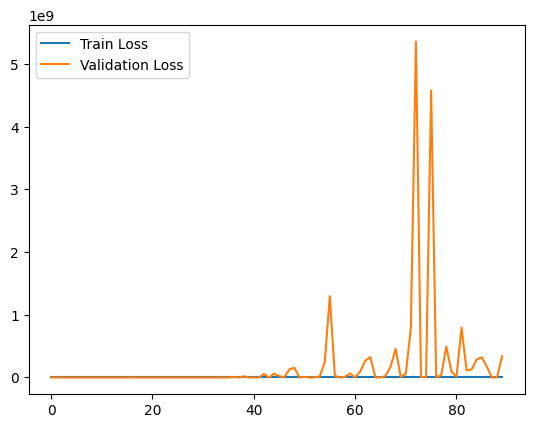

In [ ]:
plt.plot(train_history, label = 'Train Loss')
plt.plot(validation_history, label = 'Validation Loss')
plt.legend()

# Save a model

In [ ]:
model_folder = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/'
number_of_images = '3'
name = os.path.join(model_folder, "FFM_"+MODEL+"_"+CRITERION+"_"+str(LR)+"_Adaptive-"+str(ADAPTIVE)+"_"+str(AUGMENT)+"x_"+REGION+"_"+number_of_images+"_"+OUTPUT+"_"+str(EPOCHS)+"epochs_WL-"+str(WL)+"_"+str(date.today())+".pt")
print(name)
torch.save(model, name)

/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/FFM_UNet_MSE_0.001_Adaptive-True_0x_BAQ_3_FFM_90epochs_WL-False_2024-07-04.pt


# Load a model

In [ ]:
LOAD_MODEL = "UNet" # "EffNet_FT", "EffNet_LP"，"ResNet18_FT", "ResNet18_LP"，"UNet"， "AttUNet" "UNet++"
LOAD_CRITERION = "MSE" # "MAE", "MAPE"
LOAD_LR = 0.001
LOAD_ADAPTIVE = True
LOAD_REGION = "BAQ" # "BAQ", "BA", "BQ", "AQ", "B“, "A", "Q"
LOAD_AUGMENT = 0
LOAD_OUTPUT = "FM" # "FM", "FFM"
LOAD_EPOCHS = 90
LOAD_WL = False
LOAD_date = '2024-07-03'

model_folder = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/'
model_name = os.path.join(model_folder, LOAD_MODEL+"_"+LOAD_CRITERION+"_"+str(LOAD_LR)+"_Adaptive-"+str(LOAD_ADAPTIVE)+"_"+str(LOAD_AUGMENT)+"x_"+LOAD_REGION+"_"+LOAD_OUTPUT+"_"+str(LOAD_EPOCHS)+"epochs_WL-"+str(LOAD_WL)+"_"+LOAD_date+".pt")
model = torch.load(model_name)
model.to('cuda')
model.eval()

UNet(
  (inc): inconv(
    (conv): double_conv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.1, inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): LeakyReLU(negative_slope=0.1, inplace=True)
      )
    )
  )
  (down1): down(
    (mpconv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): double_conv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.1, inplace=True)
          (3): Conv2d(128, 128, k

# See Test Performance


In [ ]:
normalization_factors = 0.5
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(normalization_factors, normalization_factors)])
REGION = "BAQ"
OUTPUT = "FFM"
test_dataset = TestPatientDataset(transform = tx_X,
                 augmented_dataset = False,
                 augment = 0,
                 threshold = False,
                 speckle = True,
                 despeckle = False,
                 region_combination = REGION,
                 number_of_image = 2,
                 crop = [1, 1, 1],
                 output = OUTPUT)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
print(len(test_loader))

7


In [ ]:
true_labels = []
prediction = []
WL = False
for ith_batch, batch in enumerate(test_loader):
  X_train = [image.to('cuda') for image in batch[0]]
  y_train = batch[1].to('cuda').float()[0]
  if WL:
    if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
      additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
      y_pred = model(X_train, additional_data_train)
    if MODEL == "UNet":
      weight = batch[2].to('cuda').float()[0]
      length = batch[3].to('cuda').float()[0]
      y_pred = model(X_train, weight, length)
  else:
    y_pred = model(X_train) #[0] REMOVED for effnet
  true_labels.append(y_train)
  prediction.append(y_pred)

In [ ]:
GT_FM = []
Pred_FM = []
for i in range(len(true_labels)):
  gt = torch.Tensor.tolist(true_labels[i])
  GT_FM.append(gt)
  pred = torch.Tensor.tolist(prediction[i])
  Pred_FM.append(pred)
print(GT_FM)
print(Pred_FM)

[1.9401999711990356, 2.177799940109253, 1.330899953842163, 2.4855000972747803, 2.0833001136779785, 2.3958001136779785, 2.1493000984191895]
[-0.21016955375671387, -0.06599053740501404, -0.17290045320987701, -0.1687064915895462, -0.311703085899353, -0.21400298178195953, -0.18751712143421173]


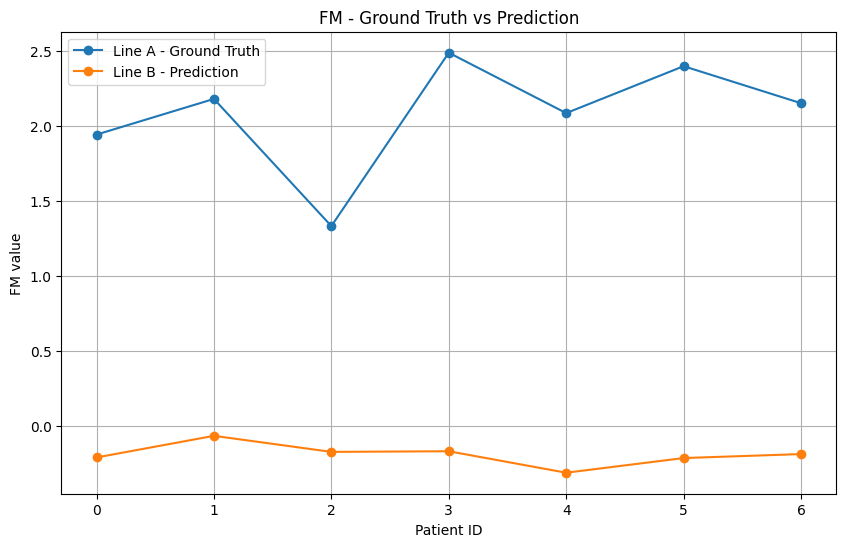

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(GT_FM, label=f'Line A - Ground Truth', marker='o')
plt.plot(Pred_FM, label=f'Line B - Prediction', marker='o')
plt.xlabel('Patient ID')
plt.ylabel('FM value')
plt.legend()
plt.title('FM - Ground Truth vs Prediction')
plt.grid(True)
plt.show()

In [ ]:
y_true = torch.tensor(GT_FM)
y_pred = torch.tensor(Pred_FM)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("MAE:", mae.item())
print("MSE:", mse.item())
print("RMSE:", rmse)
print("MAPE:", mape.item())

MAE: 2.2705414295196533
MSE: 5.281819820404053
RMSE: 2.2982210120882747
MAPE: 109.46576690673828


# More analysis

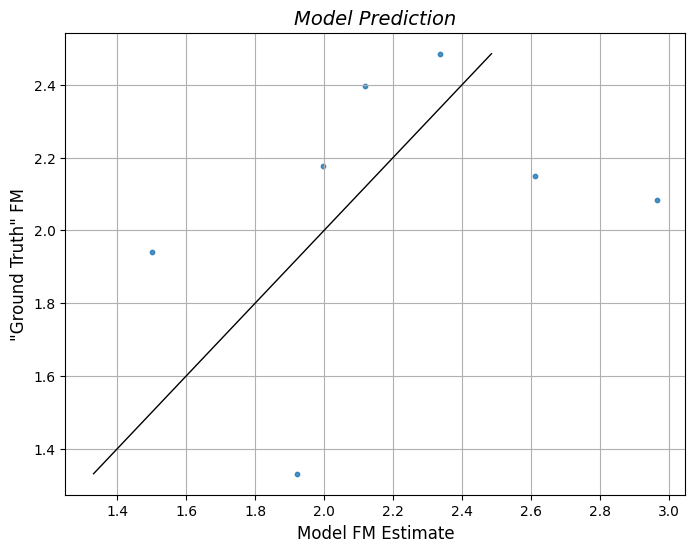

In [ ]:
# Example data
ground_truth = GT_FM
prediction = Pred_FM

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(prediction, ground_truth, s=10, alpha=0.8)
plt.plot([min(ground_truth), max(ground_truth)], [min(ground_truth), max(ground_truth)], color='black', linewidth=1)

# Add labels and title
plt.xlabel('Model FM Estimate')
plt.ylabel('"Ground Truth" FM')
plt.title('Model Prediction')
plt.grid(True)

# Adjust font and formatting
plt.title('Model Prediction', fontsize=14, style='italic')
plt.xlabel('Model FM Estimate', fontsize=12)
plt.ylabel('"Ground Truth" FM', fontsize=12)

# Show plot
plt.show()

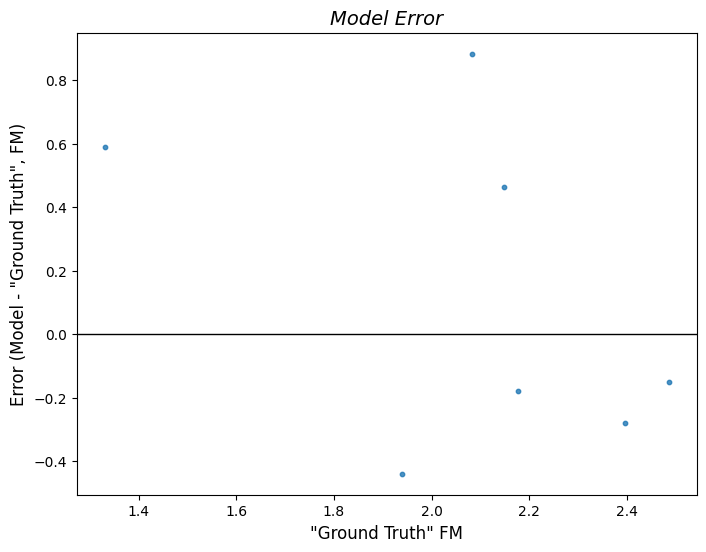

In [ ]:
ground_truth = GT_FM
prediction = Pred_FM

# Calculate error
error = difference = [a - b for a, b in zip(prediction, ground_truth)]

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(ground_truth, error, s=10, alpha=0.8)
plt.axhline(y=0, color='black', linewidth=1)

# Add labels and title
plt.xlabel('"Ground Truth" FM')
plt.ylabel('Error (Model - "Ground Truth", FM)')
plt.title('Model Error')

# Adjust font and formatting
plt.title('Model Error', fontsize=14, style='italic')
plt.xlabel('"Ground Truth" FM', fontsize=12)
plt.ylabel('Error (Model - "Ground Truth", FM)', fontsize=12)

# Show plot
plt.show()

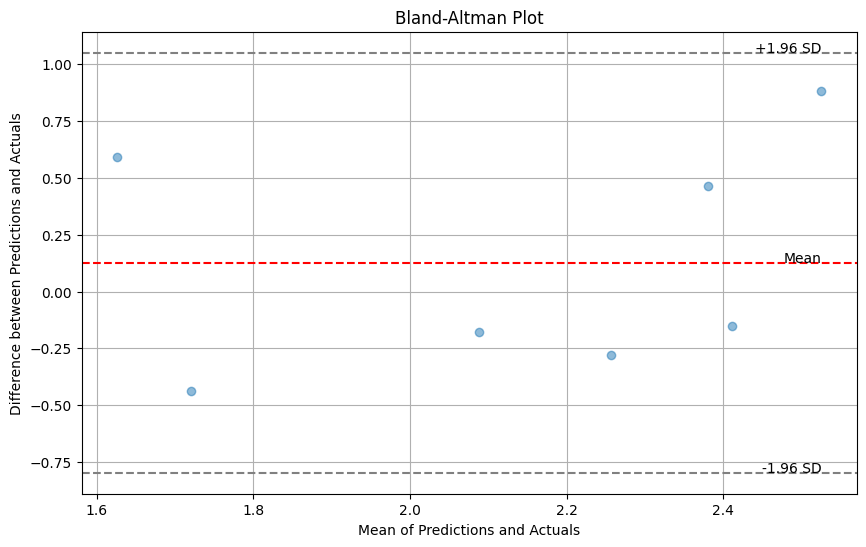

In [ ]:
def bland_altman_plot(actuals, predictions):
    differences = predictions - actuals  # Calculate the differences
    means = (predictions + actuals) / 2  # Calculate the means

    mean_difference = np.mean(differences)
    sd_difference = np.std(differences)

    plt.figure(figsize=(10, 6))
    plt.scatter(means, differences, alpha=0.5)
    plt.axhline(mean_difference, color='red', linestyle='--')
    plt.axhline(mean_difference + 1.96 * sd_difference, color='gray', linestyle='--')
    plt.axhline(mean_difference - 1.96 * sd_difference, color='gray', linestyle='--')

    plt.text(np.max(means), mean_difference, 'Mean', horizontalalignment='right')
    plt.text(np.max(means), mean_difference + 1.96 * sd_difference, '+1.96 SD', horizontalalignment='right')
    plt.text(np.max(means), mean_difference - 1.96 * sd_difference, '-1.96 SD', horizontalalignment='right')

    plt.title('Bland-Altman Plot')
    plt.xlabel('Mean of Predictions and Actuals')
    plt.ylabel('Difference between Predictions and Actuals')
    plt.grid(True)
    plt.show()

actuals = np.array(GT_FM)
predictions = np.array(Pred_FM)
bland_altman_plot(actuals, predictions)

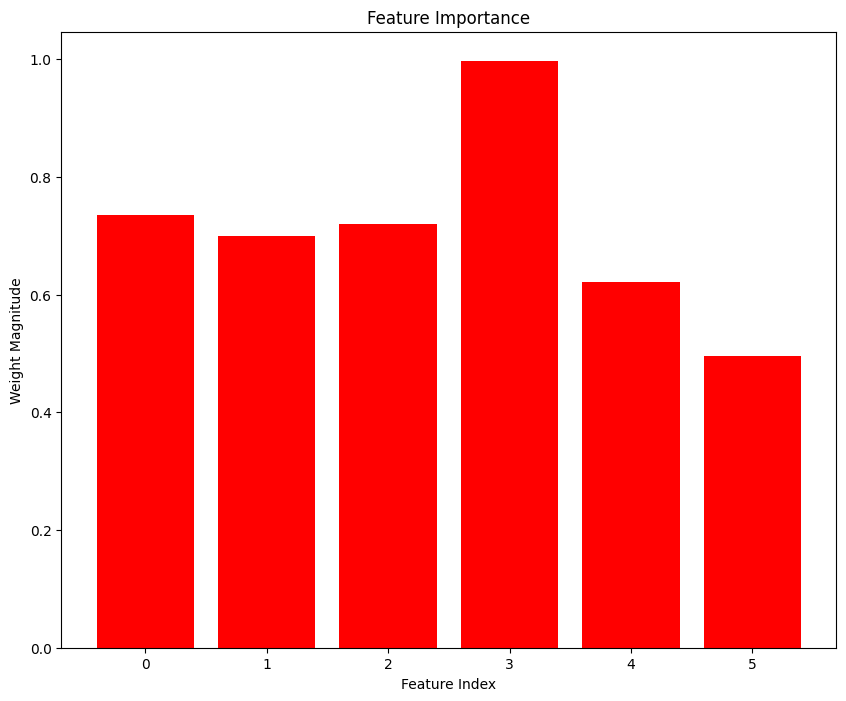

In [ ]:
def visualize_linear_layer_weights(linear_layer):
    weights = linear_layer.weight.data.cpu().numpy().squeeze()

    plt.figure(figsize=(10, 8))
    indices = np.arange(len(weights))
    plt.bar(indices, weights, color='red')
    plt.xlabel('Feature Index')
    plt.ylabel('Weight Magnitude')
    plt.title('Feature Importance')
    plt.show()

# Example usage after your model is trained:
visualize_linear_layer_weights(model.linear2)


In [ ]:
def visualize_image_weights(linear_layer):
    weights = linear_layer.weight.data.cpu().numpy().squeeze()
    weights_image = weights.reshape(8, 8)  # Reshape to 256x256 for visualization

    plt.figure(figsize=(6, 6))
    plt.imshow(weights_image, cmap='Reds')
    plt.colorbar()
    plt.title('Pixel Importance')
    plt.axis('off')  # Hide axis for better visualization
    plt.show()

# Example usage after your model is trained:
print(UNet_A)
visualize_image_weights(UNet_A.outc.conv)


NameError: name 'UNet_A' is not defined

# GradCam

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.forward_output = None
        target_layer.register_backward_hook(self.save_gradients)
        target_layer.register_forward_hook(self.save_forward_output)

    def save_gradients(self, module, input_grad, output_grad):
        self.gradients = output_grad[0]

    def save_forward_output(self, module, input, output):
        self.forward_output = output

    def __call__(self, x):
        output = self.model(x)
        self.model.zero_grad()
        output.backward(retain_graph=True)

        # Generate heatmap
        gradients = self.gradients.cpu().data.numpy()[0]
        forward_output = self.forward_output.cpu().data.numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))

        grad_cam = np.zeros(forward_output.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            grad_cam += w * forward_output[i, :, :]

        grad_cam = np.maximum(grad_cam, 0)
        grad_cam = cv2.resize(grad_cam, (x.shape[2], x.shape[3]))
        grad_cam = grad_cam - np.min(grad_cam)
        grad_cam = grad_cam / np.max(grad_cam)

        return grad_cam

def load_image(img_path):
    img = Image.open(img_path)
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(normalization_factors, normalization_factors)
    ])
    img = transform(img).unsqueeze(0).to('cuda')
    return img

def apply_grad_cam(img_path, model, target_layer):
    img = load_image(img_path)
    grad_cam = GradCAM(model, target_layer)
    heatmap = grad_cam()
    heatmap = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)
    img = cv2.imread(img_path)
    img = np.float32(cv2.resize(img, (256, 256)))
    overlaid_img = heatmap * 0.8 + img
    img = overlaid_img / np.max(overlaid_img)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  # Hide the axis
    plt.show()

In [ ]:
grad_cam_img_path = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images/58041919/58041919_AB1_R.jpg'
target_layer = UNet_A.outc.conv
UNet_A_drop = UNet_A
apply_grad_cam(grad_cam_img_path, UNet_A, target_layer)


TypeError: GradCAM.__call__() missing 1 required positional argument: 'x'

In [ ]:
grad_cam_img_path = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images/58041919/58041919_BICEP1_R.jpg'
target_layer = model.resnet.layer4[2].conv3
apply_grad_cam(grad_cam_img_path, model, target_layer)

IndexError: index 2 is out of range

In [ ]:
grad_cam_img_path = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images/58041919/58041919_QUAD1_R.jpg'
target_layer = model.resnet.layer4[2].conv3
apply_grad_cam(grad_cam_img_path, model, target_layer)

In [ ]:
print(model.regression)

In [ ]:
model_folder = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/MICCAI_models/'
model = torch.load(os.path.join(model_folder, 'Resnet18_LP_MSE_0307_MICCAI_FM_40epochs_BAQ.pt'))
model.to('cuda')
model.eval()

# P-Value

In [ ]:
MAE_list = []
MSE_list = []
RMSE_list = []
MAPE_list = []
for i in range(50):
    true_labels = []
    prediction = []
    for ith_batch, batch in enumerate(test_loader):
        X_train = [image.to('cuda') for image in batch[0]]
        y_train = torch.tensor(batch[1]).to('cuda').float()[0]
        y_pred = model(X_train)
        true_labels.append(y_train)
        prediction.append(y_pred)
    GT_FM = []
    Pred_FM = []
    for i in range(len(true_labels)):
        gt = torch.Tensor.tolist(true_labels[i])
        GT_FM.append(gt)
        pred = torch.Tensor.tolist(prediction[i])
        Pred_FM.append(pred)
    y_true = torch.tensor(GT_FM)
    y_pred = torch.tensor(Pred_FM)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    MAE_list.append(mae.item())
    MSE_list.append(mse.item())
    RMSE_list.append(rmse)
    MAPE_list.append(mape.item())

<ipython-input-84-a3eb96f5add5>:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(batch[1]).to('cuda').float()[0]


In [ ]:
print(MAE_list)
print(MSE_list)
print(RMSE_list)
print(MAPE_list)

[1.6398766040802002, 1.6302286386489868, 1.6188504695892334, 1.658190131187439, 1.6155468225479126, 1.624005675315857, 1.6431121826171875, 1.635953664779663, 1.6155627965927124, 1.641308069229126, 1.6176574230194092, 1.656886339187622, 1.6283485889434814, 1.6031526327133179, 1.6217743158340454, 1.6769039630889893, 1.6045103073120117, 1.607015609741211, 1.6249042749404907, 1.651742935180664, 1.643117904663086, 1.6478866338729858, 1.6146246194839478, 1.628217339515686, 1.611294150352478, 1.618586778640747, 1.6365959644317627, 1.6227798461914062, 1.62075936794281, 1.6349464654922485, 1.596885085105896, 1.5990558862686157, 1.6187946796417236, 1.604508638381958, 1.6175687313079834, 1.62942373752594, 1.6408932209014893, 1.6201965808868408, 1.6676393747329712, 1.601599097251892, 1.640061616897583, 1.6201581954956055, 1.640268325805664, 1.6218782663345337, 1.6017427444458008, 1.6417087316513062, 1.6293411254882812, 1.6573941707611084, 1.5841608047485352, 1.6184848546981812]
[2.809145450592041,

In [ ]:
def Average(lst):
    return sum(lst) / len(lst)
print("MAE: ", Average(MAE_list))
print("MSE: ", Average(MSE_list))
print("RMSE: ", Average(RMSE_list))
print("MAPE: ", Average(MAPE_list))

MAE:  1.6269220876693726
MSE:  2.751225357055664
RMSE:  1.6585747962212354
MAPE:  81.01597671508789


## All

In [ ]:
ResNet18_LP_MAE_MAE = [0.04648197814822197, 0.04519886523485184, 0.048376698046922684, 0.05102362483739853, 0.04200226813554764, 0.041844915598630905, 0.042984385043382645, 0.051008980721235275, 0.03912623971700668, 0.04116343706846237, 0.0450211763381958, 0.04831387847661972, 0.042990267276763916, 0.0516321174800396, 0.046422380954027176, 0.0428861565887928, 0.04016643017530441, 0.045899342745542526, 0.04886137321591377, 0.04210586100816727, 0.0482005774974823, 0.0457969531416893, 0.04226180166006088, 0.046035099774599075, 0.04964829608798027, 0.04785540699958801, 0.03990448638796806, 0.04349493980407715, 0.04840794950723648, 0.04026925563812256, 0.04563742130994797, 0.04365463927388191, 0.04339928179979324, 0.03944479674100876, 0.040992457419633865, 0.041617251932621, 0.03837668150663376, 0.03909792751073837, 0.035172682255506516, 0.0506461039185524, 0.04808040335774422, 0.05727022886276245, 0.040348608046770096, 0.04638855904340744, 0.044032737612724304, 0.04659147188067436, 0.05073476582765579, 0.048987068235874176, 0.04434164613485336, 0.04724014922976494]
ResNet18_LP_MAE_MSE = [0.0027527562342584133, 0.00225449213758111, 0.0033381369430571795, 0.0039956760592758656, 0.002309242030605674, 0.0021087194327265024, 0.0026167756877839565, 0.0030082801822572947, 0.0022921711206436157, 0.002333505777642131, 0.003380507230758667, 0.003120796289294958, 0.0020515157375484705, 0.0033971648663282394, 0.002765908371657133, 0.002648676047101617, 0.00275154085829854, 0.003036517184227705, 0.0031961104832589626, 0.002621558029204607, 0.002995713148266077, 0.0033510352950543165, 0.00205508666113019, 0.002676929347217083, 0.003501828759908676, 0.0034257001243531704, 0.002256044652312994, 0.0022732026409357786, 0.002971238223835826, 0.0022789649665355682, 0.0024914927780628204, 0.0024216126184910536, 0.0025613356847316027, 0.002258892869576812, 0.0024121077731251717, 0.0022598272189497948, 0.0023062608670443296, 0.002626908477395773, 0.001847241073846817, 0.003149143885821104, 0.0028959447517991066, 0.004257111810147762, 0.0026214667595922947, 0.0027381593827158213, 0.0026302477344870567, 0.002755427034571767, 0.0030882791616022587, 0.003100783098489046, 0.002473933156579733, 0.0029121162369847298]
ResNet18_LP_MAE_RMSE = [0.05246671548952167, 0.04748149257954208, 0.05777661242282364, 0.06321136020744898, 0.04805457346190552, 0.04592079521008431, 0.05115442979629385, 0.05484779104264177, 0.04787662394784761, 0.04830637408916271, 0.05814212956848645, 0.05586408765293637, 0.04529366111884168, 0.058285202807644404, 0.05259190405050128, 0.05146528973105676, 0.052455131858556416, 0.05510460220551188, 0.05653415324614814, 0.05120115261597738, 0.05473310833733159, 0.05788812741015481, 0.04533306366362404, 0.05173905050556188, 0.05917625165477006, 0.05852948081397246, 0.0474978383962154, 0.04767811490543412, 0.05450906551974475, 0.04773850611964694, 0.04991485528440226, 0.04920988334157127, 0.05060964023515285, 0.04752781153784394, 0.04911321383421341, 0.047537640022931246, 0.04802354492375932, 0.051253375278080694, 0.04297954250392641, 0.05611723341203755, 0.05381398286504267, 0.06524654634651371, 0.05120026132347661, 0.052327424766711206, 0.051285940904765084, 0.052492161648876365, 0.055572287712512415, 0.055684675616268484, 0.04973864851983549, 0.05396402724949955]
ResNet18_LP_MAE_MAPE = [30.901592254638672, 31.29049301147461, 31.356800079345703, 32.78160858154297, 27.16561508178711, 28.172714233398438, 27.547698974609375, 32.94705581665039, 25.157651901245117, 27.283531188964844, 28.925600051879883, 30.565792083740234, 28.0874080657959, 33.249053955078125, 30.64939308166504, 28.687849044799805, 26.136398315429688, 29.23654556274414, 32.70735168457031, 28.164243698120117, 32.25054168701172, 28.61640167236328, 28.820186614990234, 29.266759872436523, 31.26235008239746, 30.183034896850586, 25.82872772216797, 28.148048400878906, 31.04250144958496, 26.04660987854004, 30.05912971496582, 28.116592407226562, 27.098617553710938, 26.152690887451172, 25.88064956665039, 26.616254806518555, 24.730663299560547, 25.117206573486328, 22.17123031616211, 33.0120735168457, 31.038198471069336, 37.65074157714844, 25.345443725585938, 30.03291130065918, 28.688568115234375, 30.413469314575195, 33.54026794433594, 31.469860076904297, 28.77408218383789, 30.539756774902344]

ResNet18_LP_MSE_MAE = [0.045754194259643555, 0.04438377544283867, 0.04270970821380615, 0.049648113548755646, 0.05210460349917412, 0.048647522926330566, 0.04840411990880966, 0.04598831385374069, 0.04873140901327133, 0.04367019981145859, 0.04461967945098877, 0.04222412779927254, 0.04346819594502449, 0.040206294506788254, 0.046167053282260895, 0.040044497698545456, 0.04612063616514206, 0.04642218351364136, 0.04128466174006462, 0.04480713605880737, 0.04507523030042648, 0.035699617117643356, 0.04861033707857132, 0.050963979214429855, 0.0416458360850811, 0.04147512465715408, 0.04583616182208061, 0.047136884182691574, 0.039461392909288406, 0.047328151762485504, 0.044708479195833206, 0.04323362186551094, 0.050379376858472824, 0.05050204321742058, 0.03828396275639534, 0.03811041638255119, 0.04653846099972725, 0.047341424971818924, 0.04361007735133171, 0.04694709926843643, 0.044338393956422806, 0.040276139974594116, 0.05205517262220383, 0.03920074552297592, 0.040745437145233154, 0.04406485706567764, 0.04568524286150932, 0.04791707545518875, 0.04357587546110153, 0.042990513145923615]
ResNet18_LP_MSE_MSE = [0.0026983332354575396, 0.002723583485931158, 0.002449049148708582, 0.003259220626205206, 0.003017778042703867, 0.0033191211987286806, 0.0029909962322562933, 0.0029727716464549303, 0.0034355991519987583, 0.002280157757923007, 0.002660587662830949, 0.0024130619131028652, 0.0023080450482666492, 0.0021642043720930815, 0.0027824994176626205, 0.002109960187226534, 0.002598294522613287, 0.0028258354868739843, 0.002271361416205764, 0.002487652003765106, 0.0025540951173752546, 0.001824073144234717, 0.0031984068918973207, 0.0032204941380769014, 0.002233887556940317, 0.0021969606168568134, 0.00245892396196723, 0.002834501676261425, 0.002514112275093794, 0.002938333433121443, 0.0025979862548410892, 0.0022797822020947933, 0.002944402862340212, 0.003021546173840761, 0.0020311973057687283, 0.001996321137994528, 0.0026425316464155912, 0.0028481793124228716, 0.0023815776221454144, 0.002548463409766555, 0.0026431428268551826, 0.002375483512878418, 0.003579267067834735, 0.0019002265762537718, 0.002267954172566533, 0.00305644772015512, 0.0027607439551502466, 0.0030656945891678333, 0.0026208660565316677, 0.0022858930751681328]
ResNet18_LP_MSE_RMSE = [0.051945483301799586, 0.052187963036807235, 0.049487868702426274, 0.05708958421818472, 0.054934306609839605, 0.057611814749482425, 0.054690001209145106, 0.054523129463145546, 0.058613984269956926, 0.04775099745474441, 0.051580884665067044, 0.04912292655270923, 0.048042117441539245, 0.04652101000723309, 0.05274940205976387, 0.0459343029469974, 0.050973468810875396, 0.053158588082020994, 0.04765880208529966, 0.049876367186926375, 0.05053805612976477, 0.042709169322696, 0.056554459522634645, 0.05674939768911122, 0.04726401968665295, 0.04687174646689425, 0.049587538373740934, 0.053240038281930496, 0.050140924154763976, 0.054206396607055916, 0.05097044491507887, 0.04774706485319064, 0.05426235216372593, 0.05496859261287996, 0.04506880634949997, 0.04468020969058368, 0.051405560462031645, 0.053368336234352214, 0.0488014100425942, 0.05048230788867081, 0.05141150481025801, 0.04873893220905048, 0.05982697608800511, 0.04359158836580484, 0.047623042453906, 0.055285149182715605, 0.05254278214132029, 0.055368714895397686, 0.05119439477649548, 0.047811014161677566]
ResNet18_LP_MSE_MAPE = [31.967662811279297, 29.025190353393555, 29.61684799194336, 31.860580444335938, 34.25739288330078, 32.64765930175781, 31.207551956176758, 30.681842803955078, 31.11998176574707, 27.631027221679688, 29.091325759887695, 27.216690063476562, 29.260135650634766, 26.15511131286621, 30.684310913085938, 25.148540496826172, 30.066057205200195, 29.52933692932129, 27.456602096557617, 29.988616943359375, 29.78766632080078, 22.502334594726562, 32.1391487121582, 32.46160888671875, 25.811296463012695, 27.651905059814453, 30.485572814941406, 30.829065322875977, 25.83226776123047, 30.184968948364258, 28.625869750976562, 28.20488739013672, 32.33317184448242, 33.15891647338867, 24.726926803588867, 25.531387329101562, 30.975597381591797, 30.332448959350586, 28.303054809570312, 30.86174774169922, 27.86162757873535, 25.42133903503418, 33.78288269042969, 25.779876708984375, 25.594791412353516, 28.073123931884766, 28.52013397216797, 30.401519775390625, 29.598861694335938, 28.11008071899414]

ResNet18_FT_MAE_MAE = [0.08593330532312393, 0.08392561972141266, 0.0760926753282547, 0.08168193697929382, 0.08261716365814209, 0.08572867512702942, 0.0790942907333374, 0.08333903551101685, 0.08173917979001999, 0.08225780725479126, 0.07807378470897675, 0.0871124416589737, 0.07778319716453552, 0.08865369111299515, 0.0851801186800003, 0.08442750573158264, 0.08468426018953323, 0.0864105299115181, 0.08417101204395294, 0.0883314311504364, 0.08839626610279083, 0.08576586097478867, 0.08427415788173676, 0.08118605613708496, 0.0800752267241478, 0.09003642946481705, 0.08456417173147202, 0.08204226195812225, 0.08331380784511566, 0.08565777540206909, 0.08567269891500473, 0.0893278568983078, 0.0825849175453186, 0.08682405948638916, 0.08642742782831192, 0.0827392190694809, 0.08847019076347351, 0.08170825242996216, 0.08536411821842194, 0.08424083888530731, 0.0822925716638565, 0.07704505324363708, 0.08751071244478226, 0.08867792785167694, 0.08781353384256363, 0.08306840807199478, 0.08412422239780426, 0.07966570556163788, 0.08299887180328369, 0.08525972068309784]
ResNet18_FT_MAE_MSE = [0.009196576662361622, 0.00873634684830904, 0.0070622810162603855, 0.008171508088707924, 0.008667508140206337, 0.008890840224921703, 0.007665800862014294, 0.00869958009570837, 0.008236375637352467, 0.00832404289394617, 0.008216492831707, 0.009014857932925224, 0.00727714691311121, 0.009034210816025734, 0.008654830045998096, 0.008418457582592964, 0.009310970082879066, 0.008661285042762756, 0.008411329239606857, 0.009008543565869331, 0.009351695887744427, 0.00920577347278595, 0.008323850110173225, 0.008343870751559734, 0.007457956671714783, 0.00959744118154049, 0.008581370115280151, 0.008364406414330006, 0.008461935445666313, 0.008630985394120216, 0.008702398277819157, 0.009207610972225666, 0.008418634533882141, 0.010067329742014408, 0.00880882702767849, 0.009160620160400867, 0.009649842977523804, 0.008517058566212654, 0.008355310186743736, 0.008512896485626698, 0.008239598013460636, 0.007038552314043045, 0.009238088503479958, 0.009526177309453487, 0.00944837648421526, 0.008804055862128735, 0.008351432159543037, 0.0077148242853581905, 0.008343282155692577, 0.008948583155870438]
ResNet18_FT_MAE_RMSE = [0.09589878342482569, 0.09346842701313123, 0.08403737868508504, 0.09039639422403929, 0.09309945295331405, 0.09429125211238688, 0.08755455934452697, 0.09327153958045493, 0.0907544799850259, 0.09123619289484941, 0.09064487206514774, 0.0949466056945967, 0.08530619504532605, 0.09504846561636718, 0.09303133905302072, 0.09175215301339236, 0.0964933680771848, 0.0930660251797763, 0.09171329914252817, 0.09491334766969992, 0.09670416685823019, 0.09594672205336642, 0.09123513637943019, 0.09134479050038778, 0.0863594619698084, 0.09796653092531392, 0.09263568489129959, 0.09145712883274877, 0.09198877891170375, 0.09290309679510267, 0.09328664576357731, 0.09595629719943172, 0.0917531172978997, 0.10033608394797162, 0.09385535161981169, 0.09571112871762023, 0.09823361429533072, 0.09228791126801307, 0.09140738584350686, 0.0922653590771027, 0.09077223151085709, 0.08389608044505444, 0.09611497543816966, 0.09760213783239324, 0.09720275965328999, 0.09382993052394707, 0.09138617050485832, 0.08783407246255971, 0.09134156860757635, 0.0945969510918319]
ResNet18_FT_MAE_MAPE = [64.15689849853516, 62.15416717529297, 56.428985595703125, 60.552757263183594, 61.23305130004883, 63.24955368041992, 58.53608703613281, 61.71034622192383, 60.470069885253906, 60.95521926879883, 59.098060607910156, 63.97789001464844, 57.199623107910156, 64.54521179199219, 62.587486267089844, 61.58914566040039, 63.82096862792969, 62.80856704711914, 61.98681640625, 64.4841537475586, 65.18704223632812, 64.0478286743164, 61.841190338134766, 60.71367263793945, 58.583194732666016, 66.1622314453125, 62.36311721801758, 60.75299835205078, 61.697303771972656, 62.62591552734375, 62.989437103271484, 65.08596801757812, 61.3231315612793, 65.94181060791016, 63.535987854003906, 62.80710220336914, 65.61209869384766, 61.285865783691406, 62.181556701660156, 62.03935623168945, 60.79988479614258, 56.62576675415039, 64.78043365478516, 65.67194366455078, 64.97550201416016, 61.72353744506836, 61.87525939941406, 58.68708038330078, 61.427032470703125, 63.283287048339844]

ResNet18_FT_MAPE_MAE = [0.12493553012609482, 0.12066833674907684, 0.11491549015045166, 0.11117801815271378, 0.11650792509317398, 0.12161514908075333, 0.12078776210546494, 0.11513607203960419, 0.1148051768541336, 0.12158913910388947, 0.11314775794744492, 0.12094428390264511, 0.11758378893136978, 0.11843860149383545, 0.12244564294815063, 0.11683241277933121, 0.1197398453950882, 0.12300135940313339, 0.122744120657444, 0.11461640894412994, 0.12379208952188492, 0.12167912721633911, 0.11367283761501312, 0.12011472880840302, 0.11327774822711945, 0.11828043311834335, 0.11703171581029892, 0.12012644112110138, 0.11918926239013672, 0.11594498157501221, 0.11852103471755981, 0.1220373883843422, 0.11656840890645981, 0.11775193363428116, 0.1215241327881813, 0.12557676434516907, 0.11752166599035263, 0.11936470121145248, 0.12236110121011734, 0.11385178565979004, 0.11682132631540298, 0.11424461752176285, 0.11712014675140381, 0.11936251819133759, 0.12141092121601105, 0.11788234859704971, 0.12320393323898315, 0.1165391057729721, 0.11359252035617828, 0.12006659805774689]
ResNet18_FT_MAPE_MSE = [0.028555992990732193, 0.026814138516783714, 0.02432931773364544, 0.024225549772381783, 0.026669159531593323, 0.026442566886544228, 0.02733052335679531, 0.025028366595506668, 0.02620908059179783, 0.02737623080611229, 0.024512900039553642, 0.026796843856573105, 0.026423480361700058, 0.026759739965200424, 0.026399681344628334, 0.025899941101670265, 0.025390779599547386, 0.027539487928152084, 0.02576257660984993, 0.023738114163279533, 0.026366110891103745, 0.027528297156095505, 0.026124868541955948, 0.027724143117666245, 0.02478313073515892, 0.026423264294862747, 0.025450434535741806, 0.025562871247529984, 0.027156421914696693, 0.025083381682634354, 0.025954455137252808, 0.028080591931939125, 0.026760179549455643, 0.025948550552129745, 0.026835834607481956, 0.02932114526629448, 0.024538977071642876, 0.027053778991103172, 0.02811305597424507, 0.02424478344619274, 0.025581056252121925, 0.024151036515831947, 0.026400959119200706, 0.02523340843617916, 0.027110332623124123, 0.026193883270025253, 0.027590617537498474, 0.026734966784715652, 0.024480635300278664, 0.027365583926439285]
ResNet18_FT_MAE_RMSE = [0.16898518571381396, 0.16375023211215217, 0.155978581009206, 0.15564559027605562, 0.16330694881600513, 0.16261170587182286, 0.1653194584941389, 0.15820356062840896, 0.16189218817409884, 0.16545764051899292, 0.15656596066691394, 0.16369741554640715, 0.1625530078519006, 0.16358404557046638, 0.16247978749564002, 0.16093458640599995, 0.15934484491048773, 0.16595025739103897, 0.16050724784211437, 0.1540717825017921, 0.16237644808008256, 0.16591653671679477, 0.16163189209421497, 0.16650568494098406, 0.1574265883996694, 0.16255234324629944, 0.15953192324968005, 0.15988393054816355, 0.16479205658858892, 0.1583773395490477, 0.16110386443922692, 0.1675726467295278, 0.16358538916864074, 0.16108553799807648, 0.1638164662281602, 0.1712341825287652, 0.15664921663271372, 0.1644803301039464, 0.16766948432629317, 0.1557073647782684, 0.15994078983211857, 0.15540603757844143, 0.16248371955122368, 0.15885027049451053, 0.16465215644844777, 0.16184524481746523, 0.1661042369643185, 0.16350830799906058, 0.1564628879328215, 0.16542546335567354]
ResNet18_FT_MAE_MAPE = [68.37893676757812, 65.67686462402344, 62.3962287902832, 60.05936813354492, 61.84660339355469, 66.37803649902344, 65.42724609375, 61.94781494140625, 61.54438400268555, 66.50251007080078, 60.91201400756836, 66.28731536865234, 63.479984283447266, 63.482643127441406, 67.5003433227539, 63.02922439575195, 65.67626953125, 67.54904174804688, 68.00205993652344, 62.02490997314453, 68.34039306640625, 65.48756408691406, 60.02526092529297, 64.91938781738281, 61.32472229003906, 63.004390716552734, 63.38990783691406, 66.25355529785156, 64.20060729980469, 63.46533966064453, 64.68128204345703, 65.4751205444336, 62.438499450683594, 63.516151428222656, 66.63233947753906, 68.47660064697266, 65.03461456298828, 64.2806167602539, 66.78070831298828, 61.004329681396484, 63.5670051574707, 62.18071746826172, 62.65570068359375, 65.13451385498047, 66.23446655273438, 63.71305465698242, 67.42362976074219, 62.17142868041992, 61.29935836791992, 64.83910369873047]

ResNet18_FT_MSE_MAE = [0.0793069377541542, 0.07831829786300659, 0.07808049023151398, 0.07332787662744522, 0.07595999538898468, 0.06982362270355225, 0.06791128218173981, 0.06994370371103287, 0.06740599125623703, 0.08334056288003922, 0.06566540896892548, 0.0800081118941307, 0.08098860830068588, 0.0679372027516365, 0.06821326911449432, 0.07929345220327377, 0.06864459812641144, 0.07923652976751328, 0.06809480488300323, 0.06475593149662018, 0.06944260746240616, 0.07514812797307968, 0.07589785009622574, 0.06843560934066772, 0.06677640974521637, 0.0677696242928505, 0.06941570341587067, 0.07571374624967575, 0.06169038265943527, 0.06666858494281769, 0.0746140256524086, 0.06754505634307861, 0.0671558827161789, 0.06910896301269531, 0.07180021703243256, 0.06893786042928696, 0.07578067481517792, 0.07547465711832047, 0.0679548978805542, 0.06796997040510178, 0.0671534463763237, 0.0692223459482193, 0.07495627552270889, 0.07641543447971344, 0.06642027199268341, 0.06695495545864105, 0.06715379655361176, 0.06588926166296005, 0.07579601556062698, 0.06277791410684586]
ResNet18_FT_MSE_MSE = [0.009117753244936466, 0.007482753600925207, 0.0090597253292799, 0.008618591353297234, 0.008591825142502785, 0.007298218552023172, 0.007469984702765942, 0.00715660909190774, 0.0075647421181201935, 0.010202641598880291, 0.0064291260205209255, 0.008081545121967793, 0.008214322850108147, 0.0058751702308654785, 0.007313067559152842, 0.008545489981770515, 0.006523900665342808, 0.00842555332928896, 0.006986965425312519, 0.007332307286560535, 0.006131283473223448, 0.008190153166651726, 0.007845763117074966, 0.006134436931461096, 0.007552692200988531, 0.007073162589222193, 0.006322688423097134, 0.007941261865198612, 0.005764246918261051, 0.007157476153224707, 0.008908001706004143, 0.006493265274912119, 0.006558810826390982, 0.00698823481798172, 0.007310546934604645, 0.0066163623705506325, 0.00842076726257801, 0.007611563894897699, 0.006856262683868408, 0.006785516627132893, 0.006481565535068512, 0.006887626834213734, 0.007297586649656296, 0.00822421908378601, 0.006210337392985821, 0.006257446017116308, 0.00786405336111784, 0.007316348142921925, 0.007553751580417156, 0.006041997112333775]
ResNet18_FT_MSE_RMSE = [0.09548692708919093, 0.08650291093902683, 0.0951825894230657, 0.09283636869943392, 0.09269209859800771, 0.08542961168133198, 0.08642907324949135, 0.0845967439793503, 0.08697552597208133, 0.10100812640020748, 0.08018183098758051, 0.08989741443427499, 0.09063290158716175, 0.07664965903946004, 0.08551647536675516, 0.09244181944212541, 0.08077066710968041, 0.0917908128806416, 0.08358806987430993, 0.08562889282573105, 0.07830251256009253, 0.09049946500754424, 0.08857631239261977, 0.078322646351238, 0.08690622647997398, 0.08410209622371011, 0.07951533451540736, 0.08911375800177329, 0.07592263771933278, 0.08460186849724247, 0.09438221074971778, 0.08058079966662107, 0.08098648545523494, 0.0835956626744577, 0.08550173644204336, 0.08134102513830664, 0.09176473866675593, 0.08724427714697222, 0.08280255239947866, 0.08237424735396914, 0.08050817061061885, 0.08299172750469612, 0.08542591322108471, 0.09068748030343556, 0.07880569391221563, 0.07910402023359059, 0.0886794979751117, 0.085535654220459, 0.08691232122327165, 0.07773028439632634]
ResNet18_FT_MSE_MAPE = [55.14665985107422, 53.87114334106445, 52.93476104736328, 49.97720718383789, 52.601505279541016, 48.519508361816406, 47.077362060546875, 47.30329513549805, 46.092529296875, 55.65168380737305, 44.9566650390625, 53.58168029785156, 54.385196685791016, 45.93071746826172, 47.18467712402344, 53.65856170654297, 46.34713363647461, 54.70522689819336, 47.25934600830078, 45.808143615722656, 46.72588348388672, 50.24708557128906, 51.7636833190918, 47.571136474609375, 46.350250244140625, 47.05000686645508, 46.04248046875, 49.88120651245117, 40.16265106201172, 47.137664794921875, 50.517337799072266, 44.664676666259766, 44.90895080566406, 46.99675369262695, 47.44716262817383, 47.488338470458984, 51.95676040649414, 51.78384780883789, 47.093589782714844, 45.082618713378906, 46.4314079284668, 44.704856872558594, 49.640464782714844, 53.7257194519043, 45.835693359375, 44.039424896240234, 48.75255584716797, 44.06405258178711, 50.730525970458984, 44.13511657714844]

EfficientNetB1_LP_MAE_MAE = [0.1634293496608734, 0.16510580480098724, 0.16637356579303741, 0.163960799574852, 0.15493127703666687, 0.16334280371665955, 0.158257395029068, 0.16261157393455505, 0.15580078959465027, 0.15679042041301727, 0.16648714244365692, 0.1654203236103058, 0.16201546788215637, 0.16813167929649353, 0.16738733649253845, 0.1670335829257965, 0.1695541888475418, 0.16034404933452606, 0.1666402965784073, 0.1608816534280777, 0.15877294540405273, 0.16003647446632385, 0.16882631182670593, 0.17019440233707428, 0.16529962420463562, 0.1689644157886505, 0.16883417963981628, 0.17148880660533905, 0.16616208851337433, 0.1568078249692917, 0.1626816987991333, 0.16086068749427795, 0.1643143743276596, 0.16079367697238922, 0.17233628034591675, 0.15620841085910797, 0.16542799770832062, 0.15730002522468567, 0.15595968067646027, 0.16210173070430756, 0.1646203249692917, 0.16739988327026367, 0.17313681542873383, 0.16577336192131042, 0.1644574999809265, 0.16538767516613007, 0.1582901030778885, 0.1592744141817093, 0.17163586616516113, 0.1560596227645874]
EfficientNetB1_LP_MAE_MSE = [0.028795018792152405, 0.029205629602074623, 0.030131462961435318, 0.02962569333612919, 0.026185456663370132, 0.02838108502328396, 0.02696521207690239, 0.02823818288743496, 0.026988515630364418, 0.02646375633776188, 0.02959783934056759, 0.030693775042891502, 0.027417916804552078, 0.030149277299642563, 0.02976977825164795, 0.030326705425977707, 0.031133469194173813, 0.027347708120942116, 0.029472356662154198, 0.027469854801893234, 0.027180898934602737, 0.028144365176558495, 0.03017186000943184, 0.030977029353380203, 0.029312124475836754, 0.03058239258825779, 0.030701126903295517, 0.03136945143342018, 0.029710758477449417, 0.02704581990838051, 0.02830846607685089, 0.027973875403404236, 0.028337229043245316, 0.027731407433748245, 0.03159979730844498, 0.02732953056693077, 0.029581373557448387, 0.02655770257115364, 0.026884332299232483, 0.028257399797439575, 0.029110416769981384, 0.03009919263422489, 0.03203705698251724, 0.029579168185591698, 0.029506314545869827, 0.02911374345421791, 0.027433451265096664, 0.027220508083701134, 0.03140754997730255, 0.026075854897499084]
EfficientNetB1_LP_MAE_RMSE = [0.16969095082576563, 0.17089654648960764, 0.1735841667936201, 0.172121158885621, 0.16181920980949738, 0.16846686624759172, 0.16421087685321697, 0.16804220567296466, 0.1642818177107997, 0.1626768463480955, 0.1720402259373301, 0.1751963899253963, 0.16558356441553032, 0.1736354724693159, 0.17253920786780014, 0.17414564429229262, 0.17644678856293705, 0.1653714247412234, 0.17167514864462532, 0.16574032340348932, 0.16486630624418908, 0.1677628241791324, 0.1737004893759135, 0.17600292427508188, 0.17120783999524308, 0.17487822216690616, 0.1752173704382517, 0.17711423272402527, 0.17236809007890475, 0.1644561336903568, 0.16825119933257798, 0.16725392492675392, 0.16833665389108016, 0.16652749753043264, 0.17776331823085711, 0.16531645582618437, 0.1719923648231176, 0.1629653416256157, 0.1639644238828426, 0.16809937476813996, 0.17061775045399405, 0.17349118892389, 0.17898898564581353, 0.1719859534543205, 0.1717740217433062, 0.17062749911493724, 0.16563046599311573, 0.1649863875709179, 0.1772217536796839, 0.1614801997072678]
EfficientNetB1_LP_MAE_MAPE = [101.20565795898438, 102.63710021972656, 102.7298812866211, 100.45674133300781, 95.6722412109375, 103.02073669433594, 98.26677703857422, 101.59239959716797, 95.15753173828125, 97.49685668945312, 103.58965301513672, 100.67823028564453, 102.29873657226562, 104.61517333984375, 104.66094207763672, 103.1077880859375, 104.85553741455078, 100.19425964355469, 104.06002044677734, 100.83635711669922, 98.37419128417969, 98.23194885253906, 105.65342712402344, 105.97676086425781, 102.60691833496094, 105.19034576416016, 104.98140716552734, 106.96269226074219, 103.16531372070312, 96.3152084350586, 101.45867919921875, 99.44092559814453, 103.42688751220703, 100.1710433959961, 107.46826171875, 95.59876251220703, 102.60400390625, 97.50988006591797, 95.54136657714844, 100.79924011230469, 102.51005554199219, 103.89764404296875, 107.7370376586914, 102.97277069091797, 101.52123260498047, 103.36051177978516, 97.82389068603516, 98.93377685546875, 107.02478790283203, 97.26776123046875]

EfficientNetB1_LP_MSE_MAE = [0.12478117644786835, 0.11975771188735962, 0.12532249093055725, 0.1234891265630722, 0.11913968622684479, 0.13597556948661804, 0.11827327311038971, 0.12504436075687408, 0.11924508959054947, 0.12144949287176132, 0.12004755437374115, 0.1256498396396637, 0.12103559821844101, 0.11098190397024155, 0.12764903903007507, 0.12281228601932526, 0.1216573566198349, 0.12409447133541107, 0.12189129739999771, 0.12064632028341293, 0.12798349559307098, 0.12328875064849854, 0.12854941189289093, 0.12067127227783203, 0.12163767963647842, 0.11709669977426529, 0.11764715611934662, 0.12444379180669785, 0.12029658257961273, 0.13332171738147736, 0.12540097534656525, 0.12680913507938385, 0.12175214290618896, 0.1220121756196022, 0.12739261984825134, 0.124134361743927, 0.1164189949631691, 0.13396544754505157, 0.1238667219877243, 0.1288255751132965, 0.12770915031433105, 0.1244860514998436, 0.1271555870771408, 0.12277666479349136, 0.12474416196346283, 0.1242050752043724, 0.1189364641904831, 0.11972089856863022, 0.12318152189254761, 0.12861618399620056]
EfficientNetB1_LP_MSE_MSE = [0.018390947952866554, 0.017969146370887756, 0.01861102692782879, 0.017847541719675064, 0.016472823917865753, 0.02046952210366726, 0.01619839109480381, 0.018474705517292023, 0.016971273347735405, 0.016950005665421486, 0.01749015972018242, 0.018839938566088676, 0.017592212185263634, 0.01464726310223341, 0.01880502700805664, 0.01702365279197693, 0.01652086153626442, 0.01863820105791092, 0.017440974712371826, 0.0166738573461771, 0.019022895023226738, 0.018245289102196693, 0.019009694457054138, 0.016905762255191803, 0.018021050840616226, 0.016810137778520584, 0.01696973852813244, 0.019009601324796677, 0.01726328581571579, 0.020784612745046616, 0.01872953586280346, 0.018703777343034744, 0.0171156395226717, 0.017313431948423386, 0.01945941150188446, 0.018273239955306053, 0.015759626403450966, 0.020619070157408714, 0.017649246379733086, 0.019355561584234238, 0.019152242690324783, 0.01791541650891304, 0.019684603437781334, 0.01769939996302128, 0.01796974614262581, 0.01810688152909279, 0.016407564282417297, 0.01722428947687149, 0.0181675236672163, 0.020543888211250305]
EfficientNetB1_LP_MSE_RMSE = [0.13561322926936942, 0.13404904464742656, 0.1364222376587805, 0.1335946919592057, 0.1283464994375217, 0.14307173761322414, 0.12727290008011843, 0.13592168891421275, 0.13027383984413526, 0.1301921874208337, 0.13225036756161557, 0.137258655705528, 0.13263563693541655, 0.12102587782054469, 0.13713142239492976, 0.13047472089250442, 0.12853350355554935, 0.1365217970065986, 0.13206428250049984, 0.1291272912523805, 0.13792351149541812, 0.13507512392071566, 0.13787564852813616, 0.13002216063114705, 0.13424250757720607, 0.1296539153998852, 0.1302679489672438, 0.13787531078767032, 0.13138982386667467, 0.1441686954406074, 0.13685589451245225, 0.1367617539483709, 0.1308267538490186, 0.13158051507888008, 0.1394969945980359, 0.13517854842875793, 0.12553735063100133, 0.1435934196173652, 0.13285046623829774, 0.13912426669792097, 0.13839162796327234, 0.13384848340161737, 0.14030182977346137, 0.13303909186032983, 0.13405128176420325, 0.13456181304178683, 0.12809201490497873, 0.131241340578613, 0.13478695659156453, 0.14333139297184797]
EfficientNetB1_LP_MSE_MAPE = [75.06920623779297, 70.90103149414062, 75.7563247680664, 74.64360046386719, 72.23226165771484, 83.68167877197266, 71.86627960205078, 74.80608367919922, 71.3704605102539, 74.1568374633789, 71.8401107788086, 75.31541442871094, 72.13912200927734, 66.4580307006836, 77.18006896972656, 75.06855010986328, 74.85565185546875, 74.13827514648438, 73.69441986083984, 73.52195739746094, 77.15782165527344, 73.67337036132812, 78.00799560546875, 73.07361602783203, 72.79103088378906, 69.60265350341797, 71.0478286743164, 73.95033264160156, 72.58435821533203, 80.15135192871094, 75.06874084472656, 76.64924621582031, 73.53169250488281, 73.3903579711914, 76.40189361572266, 74.60722351074219, 70.94107055664062, 81.34278106689453, 75.17255401611328, 77.86463165283203, 77.24406433105469, 75.1606674194336, 75.92247009277344, 74.26114654541016, 75.75076293945312, 74.3418960571289, 72.44755554199219, 71.84776306152344, 74.19915771484375, 76.2142333984375]

EfficientNetB1_FT_MAE_MAE = [0.04589071124792099, 0.04822453856468201, 0.04181722551584244, 0.046452783048152924, 0.05047459527850151, 0.04240960627794266, 0.04517524689435959, 0.03975015878677368, 0.04297906905412674, 0.04525323584675789, 0.04347405955195427, 0.043225325644016266, 0.05001189187169075, 0.04414248466491699, 0.04125013202428818, 0.039285432547330856, 0.04386035352945328, 0.042674917727708817, 0.05235917121171951, 0.043537646532058716, 0.049476929008960724, 0.037303753197193146, 0.04586247727274895, 0.05035332590341568, 0.04089214652776718, 0.04031690955162048, 0.04646515101194382, 0.04307316616177559, 0.048069797456264496, 0.045123837888240814, 0.05031222105026245, 0.04765567183494568, 0.052447982132434845, 0.050231702625751495, 0.04389219731092453, 0.055372171103954315, 0.044072963297367096, 0.04367338865995407, 0.046690039336681366, 0.04897050932049751, 0.04600156471133232, 0.041500695049762726, 0.04325615242123604, 0.045254193246364594, 0.04353683441877365, 0.04650326818227768, 0.04596823453903198, 0.04698188975453377, 0.04816536232829094, 0.04539619758725166]
EfficientNetB1_FT_MAE_MSE = [0.003101364942267537, 0.003267752006649971, 0.0029069448355585337, 0.002954518888145685, 0.003673673840239644, 0.003398916916921735, 0.0032443497329950333, 0.0025606704875826836, 0.0029661396984010935, 0.003327207174152136, 0.0031030108220875263, 0.0032596257515251637, 0.0036948181223124266, 0.002726130187511444, 0.003426582785323262, 0.002724181395024061, 0.002795769367367029, 0.0031619626097381115, 0.0040265596471726894, 0.00289215799421072, 0.003648866666480899, 0.0027042641304433346, 0.003536888165399432, 0.003753047436475754, 0.0027781978715211153, 0.0025889179669320583, 0.0036581933964043856, 0.00279955193400383, 0.00330946734175086, 0.0029209950007498264, 0.003170172218233347, 0.0031954701989889145, 0.003766580717638135, 0.003921921364963055, 0.003009725594893098, 0.003979595378041267, 0.003234313800930977, 0.002950346563011408, 0.0028478815220296383, 0.003715917933732271, 0.0031190775334835052, 0.0033924360759556293, 0.003091915976256132, 0.003383882809430361, 0.0030470523051917553, 0.00340653327293694, 0.0034165780525654554, 0.00358283007517457, 0.0034370191860944033, 0.002959662349894643]
EfficientNetB1_FT_MAE_RMSE = [0.05568989982274647, 0.057164254623409294, 0.05391609069246892, 0.0543554862745766, 0.060610839296611325, 0.05830023084792833, 0.05695919357746415, 0.05060306796610936, 0.05446227775626992, 0.05768194842541413, 0.05570467504696106, 0.05709313226234101, 0.06078501560674659, 0.052212356655407195, 0.05853702063927803, 0.05219369114197674, 0.05287503538880167, 0.056231331210794856, 0.06345517825341514, 0.05377878758591272, 0.060405849604826346, 0.05200253965378359, 0.05947174257913948, 0.06126212073113168, 0.05270861287798338, 0.05088141081900204, 0.060483000887889035, 0.052910792226197385, 0.057527970081959784, 0.054046230217748084, 0.05630428241469158, 0.05652849015309815, 0.06137247524451116, 0.06262524542836582, 0.0548609660404654, 0.06308403425623053, 0.056871027781560064, 0.054317092733424235, 0.05336554620754517, 0.06095832948607, 0.05584870216471915, 0.05824462272137772, 0.055604999561695276, 0.058171151006580234, 0.055200111459957714, 0.05836551441508025, 0.0584515017135185, 0.05985674627955123, 0.05862609645963479, 0.05440277888026165]
EfficientNetB1_FT_MAE_MAPE = [25.778118133544922, 27.414703369140625, 22.480960845947266, 26.637128829956055, 28.951799392700195, 22.35889434814453, 24.766111373901367, 21.820537567138672, 23.478008270263672, 25.115909576416016, 23.846975326538086, 23.045761108398438, 28.077322006225586, 25.327926635742188, 21.161375045776367, 21.740568161010742, 24.699750900268555, 22.88566017150879, 30.21016502380371, 24.02088165283203, 27.488378524780273, 19.580873489379883, 25.049983978271484, 28.539291381835938, 22.030548095703125, 21.79561424255371, 25.34295082092285, 24.678117752075195, 26.981931686401367, 26.215145111083984, 29.39579200744629, 27.684688568115234, 30.389183044433594, 27.705148696899414, 24.443681716918945, 32.483314514160156, 23.9191837310791, 24.21412467956543, 27.35285186767578, 27.05746841430664, 26.13431739807129, 21.541194915771484, 23.499467849731445, 25.036584854125977, 23.814620971679688, 25.613576889038086, 25.592771530151367, 25.14107894897461, 26.8155517578125, 26.72584342956543]

EfficientNetB1_FT_MSE_MAE = [0.11856033653020859, 0.12339349091053009, 0.12135188281536102, 0.1200593113899231, 0.11812931299209595, 0.1272939294576645, 0.11903040111064911, 0.12232811748981476, 0.12491624057292938, 0.12066663801670074, 0.11996597051620483, 0.12633591890335083, 0.11974382400512695, 0.11934149265289307, 0.12108023464679718, 0.11635281145572662, 0.11950113624334335, 0.1269296109676361, 0.1266215741634369, 0.11594188213348389, 0.12397769838571548, 0.12319733202457428, 0.12587961554527283, 0.1275530606508255, 0.11996538937091827, 0.1225413829088211, 0.12475140392780304, 0.12505143880844116, 0.12009014934301376, 0.12228627502918243, 0.1237432211637497, 0.1202547550201416, 0.12062082439661026, 0.1184147447347641, 0.12770576775074005, 0.12320717424154282, 0.11838860809803009, 0.12249632924795151, 0.12556035816669464, 0.11886253207921982, 0.12409321218729019, 0.1257452815771103, 0.12018142640590668, 0.12389323860406876, 0.11855542659759521, 0.1274009495973587, 0.12260960042476654, 0.12224044650793076, 0.12272801250219345, 0.12133936583995819]
EfficientNetB1_FT_MSE_MSE = [0.01684713177382946, 0.017644211649894714, 0.016937434673309326, 0.0167554821819067, 0.016711268573999405, 0.018473263829946518, 0.016644570976495743, 0.01718812808394432, 0.017681263387203217, 0.017718708142638206, 0.016363462433218956, 0.018706489354372025, 0.017449768260121346, 0.016885222867131233, 0.017030533403158188, 0.01558117289096117, 0.017058581113815308, 0.0183233805000782, 0.018525829538702965, 0.01558011956512928, 0.017911871895194054, 0.01759868487715721, 0.018102217465639114, 0.0194651260972023, 0.017440883442759514, 0.01778678223490715, 0.0180421844124794, 0.017799679189920425, 0.017085198312997818, 0.01704542338848114, 0.018431296572089195, 0.016954274848103523, 0.016942765563726425, 0.016031518578529358, 0.018419964239001274, 0.017604295164346695, 0.016372917219996452, 0.017680689692497253, 0.017926741391420364, 0.0160506684333086, 0.0177235659211874, 0.01810160093009472, 0.017012815922498703, 0.01753750815987587, 0.016821052879095078, 0.019048888236284256, 0.017145629972219467, 0.01750182919204235, 0.017403876408934593, 0.01696099527180195]
EfficientNetB1_FT_MSE_RMSE = [0.1297965013928706, 0.1328315160264864, 0.13014389986975697, 0.1294429688392023, 0.12927207190263257, 0.1359163854358499, 0.12901384025171772, 0.13110350141756064, 0.13297091180857268, 0.13311163789330446, 0.12791974997325065, 0.13677166868314514, 0.13209757098494032, 0.12994315244417934, 0.13050108583133777, 0.12482456845894228, 0.13060850322170953, 0.13536388181519546, 0.13610962324061796, 0.12482034916282393, 0.13383524160397386, 0.1326600349659128, 0.1345444813644882, 0.13951747595624822, 0.13206393695009822, 0.13336709577293476, 0.1343211986712425, 0.13341543834924213, 0.13071036038890652, 0.13055812264459513, 0.13576191134515306, 0.1302085820831466, 0.13016437901256406, 0.12661563323116684, 0.13572016887331548, 0.13268117863640908, 0.1279567005670139, 0.1329687545722575, 0.13389078157744977, 0.12669123266157215, 0.13312988365197126, 0.13454219014901875, 0.1304331856641503, 0.13242925718992715, 0.12969600178530977, 0.1380177098646556, 0.13094132263048006, 0.1322944790686382, 0.13192375225460573, 0.1302343859040382]
EfficientNetB1_FT_MSE_MAPE = [70.2275390625, 74.04502868652344, 73.08014678955078, 71.94461822509766, 70.01335906982422, 76.90766143798828, 71.0622329711914, 73.75009155273438, 75.79875946044922, 71.06275177001953, 72.5976791381836, 75.37065124511719, 70.71800994873047, 71.24823760986328, 72.64521789550781, 70.10150909423828, 70.70884704589844, 76.71188354492188, 76.16445922851562, 69.67138671875, 74.37132263183594, 73.968505859375, 76.04569244384766, 75.6367416381836, 70.7776107788086, 72.91680908203125, 75.04869842529297, 75.71643829345703, 71.7405014038086, 73.83815002441406, 73.24801635742188, 71.82275390625, 72.59666442871094, 71.39048767089844, 77.66297912597656, 73.92178344726562, 70.8168716430664, 73.09949493408203, 75.98790740966797, 72.26132202148438, 74.65371704101562, 75.79551696777344, 71.66231536865234, 74.72606658935547, 70.25070190429688, 76.17256927490234, 74.05661010742188, 73.0045166015625, 73.873046875, 73.02873992919922]

# Multi-UNets

In [ ]:
UNet_A = torch.load('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/UNet_MSE_A_FM_40epochs_WL-False_2024-04-10.pt')
UNet_A.to('cuda')
UNet_A.eval()
UNet_B = torch.load('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/UNet_MSE_B_FM_40epochs_WL-False_2024-04-10.pt')
UNet_B.to('cuda')
UNet_B.eval()
UNet_Q = torch.load('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/UNet_MSE_Q_FM_40epochs_WL-False_2024-04-10.pt')
UNet_Q.to('cuda')
UNet_Q.eval()

UNet(
  (inc): inconv(
    (conv): double_conv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
  )
  (down1): down(
    (mpconv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): double_conv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2

In [ ]:
class MultiUNetPatientDataset(Dataset):
    def __init__(self, transform = None,
                 augmented_dataset = False,
                 augment = 0, # this can be 0 (no augmentation), 5 (augment by 4 times plus original image), 8 and 15
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 number_of_image = 3,
                 crop = [1, 1, 1],
                 output = "FM"):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images'
        self.patients = os.listdir(self.root_dir)
        for data in test_data:
          self.patients.remove(str(data))
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.number_of_image = number_of_image
        # Crop in the order of Abdomen, Biceps, and Quadriceps
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        images_A, images_B, images_Q = self.load_patient_data(patient_path)
        if self.output == "FM":
          return images_A, images_B, images_Q, labels_dict[int(patient_id)][0], labels_dict[int(patient_id)][2], labels_dict[int(patient_id)][3]
        if self.output == "FFM":
          return images_A, images_B, images_Q, labels_dict[int(patient_id)][1], labels_dict[int(patient_id)][2], labels_dict[int(patient_id)][3]

    def preprocess(self, img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, crop):
        image = Image.open(img_path)
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height*crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
          image = image.filter(ImageFilter.MedianFilter(size=MF_size))
        if self.threshold:
          image = torch.where(image < threshold/255, torch.tensor(0.0), image)
        if self.despeckle:
          image_np = np.array(image)
          despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=10, templateWindowSize=7, searchWindowSize=21)
          image = Image.fromarray(despeckled_image)
        if not self.augmented_dataset:
          image = self.transform(image)
        images.append(image)

        ## Augmentation
        if self.augment >= 5:
          imx = image
          imx = TF.hflip(imx)
          images.append(imx)
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 8:
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 15:
          imx = image
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([30])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        return images

    def load_patient_data(self, patient_path):
        images_A = []
        images_B = []
        images_Q = []
        threshold = 100
        AB = 0
        BICEP = 0
        QUAD = 0
        MF_size = 5
        h = 10
        templateWindowSize = 7
        searchWindowSize = 21
        for img_file in os.listdir(patient_path):
          # Process Abdomen images
          if 'AB' in img_file and AB < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_A = self.preprocess(img_path, MF_size, images_A, threshold, h, templateWindowSize, searchWindowSize, self.crop[0])
              AB += 1
          # Process Bicep images
          elif 'BICEP' in img_file and BICEP < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_B = self.preprocess(img_path, MF_size, images_B, threshold, h, templateWindowSize, searchWindowSize, self.crop[1])
              BICEP += 1
          # Process Quad images
          elif 'QUAD' in img_file and QUAD < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_Q = self.preprocess(img_path, MF_size, images_Q, threshold, h, templateWindowSize, searchWindowSize, self.crop[2])
              QUAD += 1
        return images_A, images_B, images_Q

32
9


NameError: name 'im_converterX' is not defined

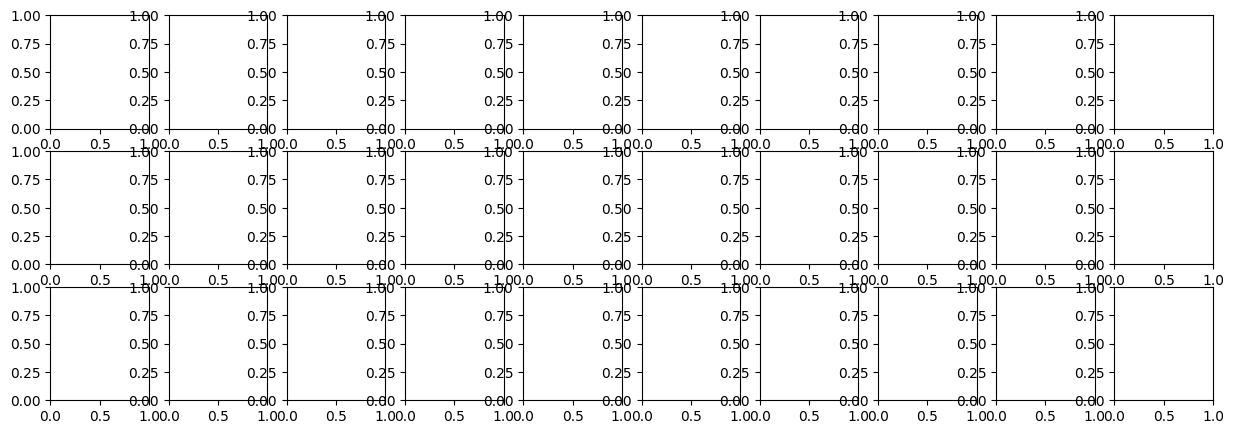

In [ ]:
normalization_factors = 0.5
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(normalization_factors, normalization_factors)])
OUTPUT = "FM"
multi_UNet_dataset = MultiUNetPatientDataset(transform = tx_X,
                 augmented_dataset = False,
                 augment = 5,
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 number_of_image = 2,
                 crop = [1, 1, 1],
                 output = OUTPUT)

train_size = int(0.8 * len(multi_UNet_dataset))  # 80% for training
test_size = len(multi_UNet_dataset) - train_size  # Remaining 20% for testing
train_dataset, test_dataset = random_split(multi_UNet_dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
print(len(train_loader))
print(len(test_loader)) # Show if we load the image successfully
for i in range(1):
  first_batch = next(iter(train_loader))
  first_batch_images_A = first_batch[0]
  first_batch_images_B = first_batch[1]
  first_batch_images_Q = first_batch[2]
  first_batch_label = first_batch[3]  # Unused in the plot
  first_batch_W = first_batch[4]       # Unused in the plot
  first_batch_L = first_batch[5]       # Unused in the plot

  batch_size = len(first_batch_images_A)
  fig, axs = plt.subplots(3, batch_size, figsize=(15, 5))

  for i in range(batch_size):
      img = im_converterX(first_batch_images_A[i][0])
      axs[0, i].imshow(img)
      axs[0, i].axis('off')
  for i in range(batch_size):
      img = im_converterX(first_batch_images_B[i][0])
      axs[1, i].imshow(img)
      axs[1, i].axis('off')
  for i in range(batch_size):
      img = im_converterX(first_batch_images_Q[i][0])
      axs[2, i].imshow(img)
      axs[2, i].axis('off')

  plt.show()
  print(first_batch_label)

  print(first_batch_W)
  print(first_batch_L)

In [ ]:
# Define a simple linear regression model
class LinearRegression(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)

In [ ]:
class RegressionNN(nn.Module):
    def __init__(self):
        super(RegressionNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 7),  # Input layer with 3 features going to hidden layer with 10 neurons
            nn.ReLU(),         # Activation function
            nn.Linear(7, 1)   # Output layer producing a single output
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
linear_model = RegressionNN().cuda()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.00002)

In [ ]:
linear_model = LinearRegression(3, 1).cuda()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.0001)

NameError: name 'LinearRegression' is not defined

In [ ]:
epochs = 10

train_running_loss_history = []
validation_running_loss_history =[]
for e in range(epochs):
  train_running_loss = 0.0
  validation_running_loss = 0.0
  linear_model.train()
  for ith_batch, batch in enumerate(train_loader):
    images_A = [image.to('cuda') for image in batch[0]]
    images_B = [image.to('cuda') for image in batch[1]]
    images_Q = [image.to('cuda') for image in batch[2]]
    A_pred = UNet_A(images_A).unsqueeze(1)
    B_pred = UNet_B(images_B).unsqueeze(1)
    Q_pred = UNet_Q(images_Q).unsqueeze(1)
    combined_input = torch.cat((A_pred, B_pred, Q_pred), 1)
    y_train = batch[3].to('cuda').float()[0]
    y_pred = linear_model(combined_input).to('cuda').float()[0][0]
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if ith_batch % 5 == 0:
      print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
    train_running_loss += loss.item()
  else:
    with torch.no_grad():
      model.eval()
      for ith_batch, batch in enumerate(test_loader):
        images_A = [image.to('cuda') for image in batch[0]]
        images_B = [image.to('cuda') for image in batch[1]]
        images_Q = [image.to('cuda') for image in batch[2]]
        A_pred = UNet_A(images_A).unsqueeze(1)
        B_pred = UNet_B(images_B).unsqueeze(1)
        Q_pred = UNet_Q(images_Q).unsqueeze(1)
        combined_input = torch.cat((A_pred, B_pred, Q_pred), 1)
        y_val = batch[3].to('cuda').float()[0]
        y_out = linear_model(combined_input).to('cuda').float()[0][0]
        val_loss = criterion(y_val, y_out)
        validation_running_loss += val_loss.item()
      print("================================================================================")
      print("Epoch {} completed".format(e + 1))
      train_epoch_loss = train_running_loss / len(train_loader)
      validation_epoch_loss = validation_running_loss / len(test_loader)
      print("Average train loss is {}: ".format(train_epoch_loss))
      print("Average validation loss is {}".format(validation_epoch_loss))
      print("================================================================================")
      train_running_loss_history.append(train_epoch_loss)
      validation_running_loss_history.append(validation_epoch_loss)
  torch.cuda.empty_cache()

Epoch:  1 Batch:  0 Current Loss:  0.07158640772104263
Epoch:  1 Batch:  5 Current Loss:  0.03588522598147392
Epoch:  1 Batch:  10 Current Loss:  0.23172783851623535
Epoch:  1 Batch:  15 Current Loss:  0.05797595530748367
Epoch:  1 Batch:  20 Current Loss:  0.1268920600414276
Epoch:  1 Batch:  25 Current Loss:  0.16078290343284607
Epoch:  1 Batch:  30 Current Loss:  0.10223107039928436
Epoch 1 completed
Average train loss is 0.11802461778279394: 
Average validation loss is 0.08522540628910065
Epoch:  2 Batch:  0 Current Loss:  0.026791000738739967
Epoch:  2 Batch:  5 Current Loss:  0.22876839339733124
Epoch:  2 Batch:  10 Current Loss:  0.07502014935016632
Epoch:  2 Batch:  15 Current Loss:  0.32114318013191223
Epoch:  2 Batch:  20 Current Loss:  0.04136683791875839
Epoch:  2 Batch:  25 Current Loss:  0.1246686652302742
Epoch:  2 Batch:  30 Current Loss:  0.14696349203586578
Epoch 2 completed
Average train loss is 0.11594001622870564: 
Average validation loss is 0.08357122614979744
Epo

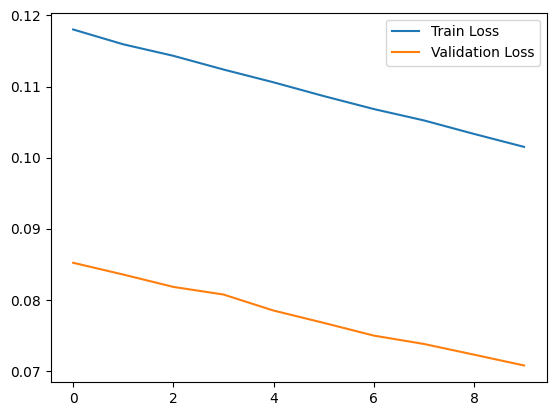

In [ ]:
plt.plot(train_running_loss_history, label = 'Train Loss')
plt.plot(validation_running_loss_history, label = 'Validation Loss')
plt.legend()

In [ ]:
class MultiUNetTestPatientDataset(Dataset):
    def __init__(self, transform = None,
                 augmented_dataset = False,
                 augment = 0, # this can be 0 (no augmentation), 5 (augment by 4 times plus original image), 8 and 15
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 number_of_image = 3,
                 crop = [1, 1, 1],
                 output = "FM"):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images'
        self.patients = ['17042418', '9021218', '35080318', '58041919', '65050619']#, '6121817', '28062718', '12032118'] #'27061918', '50102518', '57032919', '67062119']
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.number_of_image = number_of_image
        # Crop in the order of Abdomen, Biceps, and Quadriceps
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        images_A, images_B, images_Q = self.load_patient_data(patient_path)
        if self.output == "FM":
          return images_A, images_B, images_Q, test_labels_dict[int(patient_id)][0], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]
        if self.output == "FFM":
          return images_A, images_B, images_Q, test_labels_dict[int(patient_id)][1], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]

    def preprocess(self, img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, crop):
        image = Image.open(img_path)
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height*crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
          image = image.filter(ImageFilter.MedianFilter(size=MF_size))
        if self.threshold:
          image = torch.where(image < threshold/255, torch.tensor(0.0), image)
        if self.despeckle:
          image_np = np.array(image)
          despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=10, templateWindowSize=7, searchWindowSize=21)
          image = Image.fromarray(despeckled_image)
        if not self.augmented_dataset:
          image = self.transform(image)
        images.append(image)

        ## Augmentation
        if self.augment >= 5:
          imx = image
          imx = TF.hflip(imx)
          images.append(imx)
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 8:
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 15:
          imx = image
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([30])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        return images

    def load_patient_data(self, patient_path):
        images_A = []
        images_B = []
        images_Q = []
        threshold = 100
        AB = 0
        BICEP = 0
        QUAD = 0
        MF_size = 5
        h = 10
        templateWindowSize = 7
        searchWindowSize = 21
        for img_file in os.listdir(patient_path):
          # Process Abdomen images
          if 'AB' in img_file and AB < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_A = self.preprocess(img_path, MF_size, images_A, threshold, h, templateWindowSize, searchWindowSize, self.crop[0])
              AB += 1
          # Process Bicep images
          elif 'BICEP' in img_file and BICEP < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_B = self.preprocess(img_path, MF_size, images_B, threshold, h, templateWindowSize, searchWindowSize, self.crop[1])
              BICEP += 1
          # Process Quad images
          elif 'QUAD' in img_file and QUAD < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_Q = self.preprocess(img_path, MF_size, images_Q, threshold, h, templateWindowSize, searchWindowSize, self.crop[2])
              QUAD += 1
        return images_A, images_B, images_Q

In [ ]:
normalization_factors = 0.5
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(normalization_factors, normalization_factors)])
OUTPUT = "FM"
multi_UNet_dataset = MultiUNetTestPatientDataset(transform = tx_X,
                 augmented_dataset = False,
                 augment = 5,
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 number_of_image = 2,
                 crop = [1, 1, 1],
                 output = OUTPUT)

test_loader = DataLoader(multi_UNet_dataset, batch_size=1, shuffle=False)
print(len(test_loader))

5


In [ ]:
true_labels = []
prediction = []
for ith_batch, batch in enumerate(test_loader):
  images_A = [image.to('cuda') for image in batch[0]]
  images_B = [image.to('cuda') for image in batch[1]]
  images_Q = [image.to('cuda') for image in batch[2]]
  A_pred = UNet_A(images_A).unsqueeze(1)
  B_pred = UNet_B(images_B).unsqueeze(1)
  Q_pred = UNet_Q(images_Q).unsqueeze(1)
  print("Abdomen prediction:", A_pred)
  print("Biceps prediction:", B_pred)
  print("Quadriceps prediction:", Q_pred)
  combined_input = torch.cat((A_pred, B_pred, Q_pred), 1)
  y_train = batch[3].to('cuda').float()[0]
  y_pred = linear_model(combined_input).to('cuda').float()[0][0]
  # y_pred = (A_pred[0][0]+B_pred[0][0]+Q_pred[0][0])/3
  print("Ground truth:", y_train)
  print("Linear regression prediction based on A+B+Q:", y_pred)
  true_labels.append(y_train)
  prediction.append(y_pred)

Abdomen prediction: tensor([[0.1717]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Biceps prediction: tensor([[0.1800]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Quadriceps prediction: tensor([[0.1988]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Ground truth: tensor(0.1880, device='cuda:0')
Linear regression prediction based on A+B+Q: tensor(-0.1037, device='cuda:0', grad_fn=<SelectBackward0>)
Abdomen prediction: tensor([[0.1820]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Biceps prediction: tensor([[0.2049]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Quadriceps prediction: tensor([[0.1645]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Ground truth: tensor(0.1125, device='cuda:0')
Linear regression prediction based on A+B+Q: tensor(-0.1027, device='cuda:0', grad_fn=<SelectBackward0>)
Abdomen prediction: tensor([[0.1698]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Biceps prediction: tensor([[0.1702]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Quadric

In [ ]:
GT_FM = []
Pred_FM = []
for i in range(len(true_labels)):
  gt = torch.Tensor.tolist(true_labels[i])
  GT_FM.append(gt)
  pred = torch.Tensor.tolist(prediction[i])
  Pred_FM.append(pred)
print(GT_FM)
print(Pred_FM)

[0.18799999356269836, 0.11249999701976776, 0.15880000591278076, 0.1216999962925911, 0.22089999914169312]
[-0.10068091005086899, -0.10115548223257065, -0.10192520916461945, -0.10443884879350662, -0.10454237461090088]


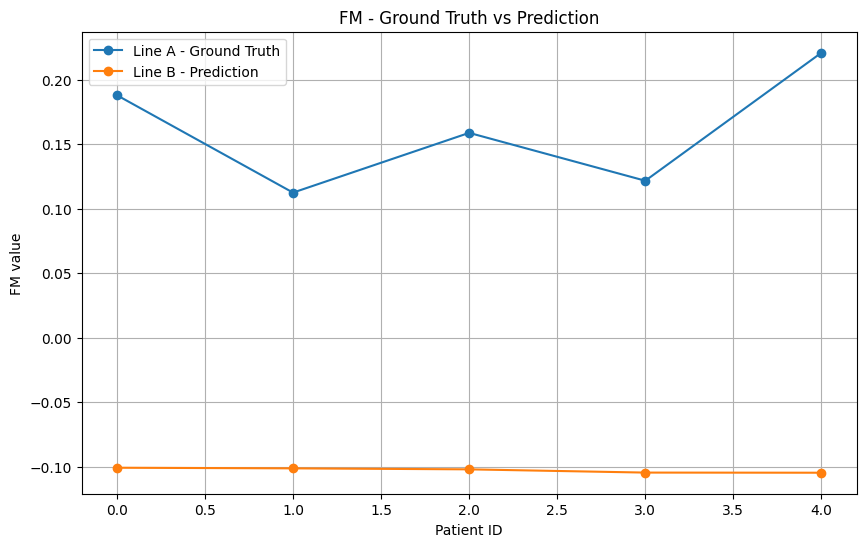

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(GT_FM, label=f'Line A - Ground Truth', marker='o')
plt.plot(Pred_FM, label=f'Line B - Prediction', marker='o')
plt.xlabel('Patient ID')
plt.ylabel('FM value')
plt.legend()
plt.title('FM - Ground Truth vs Prediction')
plt.grid(True)
plt.show()

In [ ]:
mse_list = []
for i in range(len(true_labels)):
  mse = F.mse_loss(true_labels[i], prediction[i])
  mse_list.append(mse.item())
average_mse = sum(mse_list) / len(mse_list)
print("Average MSE between true labels and predictions:", average_mse)

Average MSE between true labels and predictions: 0.07080289423465728


In [ ]:
def mean_absolute_error(y_true, y_pred):
    return torch.mean(torch.abs(y_true - y_pred))
def mean_squared_error(y_true, y_pred):
    return torch.mean((y_true - y_pred)**2)
def root_mean_squared_error(y_true, y_pred):
    return math.sqrt(torch.mean((y_true - y_pred)**2))
def mean_absolute_percentage_error(y_true, y_pred):
    return torch.mean(torch.abs((y_true - y_pred) / y_true)) * 100
def r_squared(y_true, y_pred):
    ss_residual = torch.sum((y_true - y_pred)**2)
    ss_total = torch.sum((y_true - torch.mean(y_true))**2)
    r2 = 1 - (ss_residual / ss_total)
    return r2

In [ ]:
y_true = torch.tensor(GT_FM)
y_pred = torch.tensor(Pred_FM)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("MAE:", mae.item())
print("MSE:", mse.item())
print("RMSE:", rmse)
print("MAPE:", mape.item())

MAE: 0.2629285454750061
MSE: 0.07080289721488953
RMSE: 0.26608813805746684
MAPE: 168.15931701660156
